In [1]:
import torch
import torch.nn as nn
import numpy as np

class DAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [2]:
import torch
import torch.nn as nn


def forward_k(model: nn.Module, x: torch.Tensor, k: int) -> torch.Tensor:
    """
    Feed 'x' through 'model' k times (re-feeds).
    """
    for _ in range(k):
        x = model(x)
    return x

def stacked_dae_loss(model, noisy, clean, k, weights=None):
    h = noisy
    losses = []
    for t in range(k):
        h = model(h)
        losses.append(torch.mean((h - clean) ** 2))  # MSE_t

    losses = torch.stack(losses)  # [k]
    if weights is None:
        weights = torch.ones(k, device=losses.device) / k
    else:
        weights = weights.to(losses.device)
        weights = weights / weights.sum()

    L_rec = (weights * losses).sum()

    # Optional monotonicity regularizer
    mono = torch.relu(losses[1:] - losses[:-1]).sum()
    L = L_rec + 0.0 * mono

    return L, h   # train objective + final reconstruction

In [3]:
import torch
from torchvision import datasets, transforms
def add_noise(img, noise_factor=0.81):
    """
    Add Gaussian noise to an input image tensor in [0,1]
    """
    noisy= img + noise_factor * torch.rand_like(img)
    return torch.clamp(noisy, 0., 1.)


In [4]:
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
# from .data_processing import add_noise
@torch.no_grad()
def plot_refeed_curves(models, loader, device, max_refeeds=20, criterion=torch.nn.MSELoss()):
    """
    Plot reconstruction loss vs. number of re-feeds for each model.
    Adds reference lines for the 1-pass (baseline) loss.

    Args:
        models (dict): {"AE": model_ae, "DAE": model_dae, "sDAE": model_sdae}
        loader: DataLoader with clean test data
        device: torch.device
        max_refeeds (int): maximum number of times to re-feed the model
        criterion: loss function (default: MSE)
    """
    plt.figure(figsize=(10, 6))

    for name, model in models.items():
        model.eval()
        refeed_losses = []

        for k in range(1, max_refeeds + 1):
            total, count = 0.0, 0
            for imgs, _ in loader:
                imgs = imgs.to(device, non_blocking=True)

                # Choose input (noisy for DAE/sDAE, clean for AE)
                if name == "AE":
                    inputs = imgs
                else:
                    inputs = imgs + 0.81 * torch.randn_like(imgs)
                    inputs = torch.clamp(inputs, 0., 1.)

                out = inputs
                for _ in range(k):
                    out = model(out)

                loss = criterion(out, imgs)
                bsz = imgs.size(0)
                total += loss.item() * bsz
                count += bsz

            refeed_losses.append(total / max(count, 1))

        # Plot loss vs. re-feeds and capture line handle
        (line,) = plt.plot(range(1, max_refeeds + 1), refeed_losses,
                           marker="o", label=f"{name} Loss")

        # Use same color for baseline
        plt.axhline(y=refeed_losses[0], linestyle="--", alpha=0.7,
                    color=line.get_color(), label=f"{name} 1-pass reference")

    plt.xlabel("Number of Re-feeds (k)")
    plt.ylabel("Reconstruction Loss (MSE)")
    plt.title("Reconstruction Loss vs. Number of Re-feeds")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_loss_curves(history, num_epochs, show_sdae_multi=False):
    """
    Plot training and validation losses for AE, DAE, and sDAE.
    By default, all curves are final-pass MSE for comparability.
    Optionally overlay sDAE's multi-step training loss as a diagnostic.

    Args:
        history (dict): loss history dictionary with keys:
            - "AE": {"train": [], "val": []}
            - "DAE": {"train": [], "val": []}
            - "sDAE": {"train": [], "val_final": [], "val_multi": [], "train_multi": [] (optional)}
        num_epochs (int): number of epochs
        show_sdae_multi (bool): whether to overlay sDAE's multi-step train loss
    """
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(10, 6))

    # AE
    plt.plot(epochs, history["AE"]["train"], 'b--', label="AE Train")
    plt.plot(epochs, history["AE"]["val"], 'b-', label="AE Val")

    # DAE
    plt.plot(epochs, history["DAE"]["train"], 'g--', label="DAE Train")
    plt.plot(epochs, history["DAE"]["val"], 'g-', label="DAE Val")

    # sDAE (final-pass for comparability)
    plt.plot(epochs, history["sDAE"]["train"], 'r--', label="sDAE Train (final)")
    plt.plot(epochs, history["sDAE"]["val_final"], 'r-', label="sDAE Val (final)")

    # Optional: overlay diagnostic multi-step train loss
    if show_sdae_multi and "train_multi" in history["sDAE"]:
        plt.plot(epochs, history["sDAE"]["train_multi"], 'r:', label="sDAE Train (multi-step)")

    # Optional: overlay diagnostic val_multi if desired
    # plt.plot(epochs, history["sDAE"]["val_multi"], 'r:', label="sDAE Val (multi-step)")

    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title("Autoencoder Training/Validation Loss (Final-Pass)")
    plt.legend()
    plt.grid(True)
    plt.show()

@torch.no_grad()
def evaluate(model: nn.Module,
             loader,
             *,
             denoising: bool = False,
             re_feeds: int = 1,
             stacked: bool = False,
             multi_step: bool = False,
             noise_factor: float = 0.81,
             device: torch.device = torch.device("cpu"),
             criterion: nn.Module = nn.MSELoss()) -> float:
    """
    Evaluate a model on clean MNIST reconstruction.

    Args:
        model: autoencoder
        loader: DataLoader
        denoising: if True, add Gaussian noise to inputs
        re_feeds: number of re-feeds (default 1)
        stacked: if True, compute stacked loss across steps
        multi_step: if True, return multi-step loss; otherwise final-step loss
        noise_factor: noise std for denoising AEs
        device: torch device
        criterion: loss function (default MSE)

    Returns:
        Average loss across dataset
    """
    model.eval()
    total, count = 0.0, 0

    for imgs, _ in loader:
        imgs = imgs.to(device, non_blocking=True)
        inputs = add_noise(imgs, noise_factor) if denoising else imgs

        if stacked:
            # stacked DAE: unroll k steps
            h = inputs
            losses = []
            for _ in range(re_feeds):
                h = model(h)
                losses.append(criterion(h, imgs))
            if multi_step:
                loss = torch.stack(losses).mean()   # average across steps
            else:
                loss = losses[-1]                   # final step only
        else:
            # AE or single-pass DAE
            recon = model(inputs)
            loss = criterion(recon, imgs)

        bsz = imgs.size(0)
        total += loss.item() * bsz
        count += bsz

    return total / max(count, 1)

Epoch [001/20] Train Loss: 0.045515 | Val Loss: 0.024404
Epoch [002/20] Train Loss: 0.020191 | Val Loss: 0.016609
Epoch [003/20] Train Loss: 0.015005 | Val Loss: 0.013023
Epoch [004/20] Train Loss: 0.012333 | Val Loss: 0.011172
Epoch [005/20] Train Loss: 0.010715 | Val Loss: 0.010087
Epoch [006/20] Train Loss: 0.009599 | Val Loss: 0.008983
Epoch [007/20] Train Loss: 0.008696 | Val Loss: 0.008599
Epoch [008/20] Train Loss: 0.008082 | Val Loss: 0.007772
Epoch [009/20] Train Loss: 0.007607 | Val Loss: 0.007390
Epoch [010/20] Train Loss: 0.007229 | Val Loss: 0.007120
Epoch [011/20] Train Loss: 0.006882 | Val Loss: 0.006972
Epoch [012/20] Train Loss: 0.006588 | Val Loss: 0.006664
Epoch [013/20] Train Loss: 0.006316 | Val Loss: 0.006416
Epoch [014/20] Train Loss: 0.006071 | Val Loss: 0.006197
Epoch [015/20] Train Loss: 0.005847 | Val Loss: 0.005929
Epoch [016/20] Train Loss: 0.005642 | Val Loss: 0.005739
Epoch [017/20] Train Loss: 0.005470 | Val Loss: 0.005659
Epoch [018/20] Train Loss: 0.00

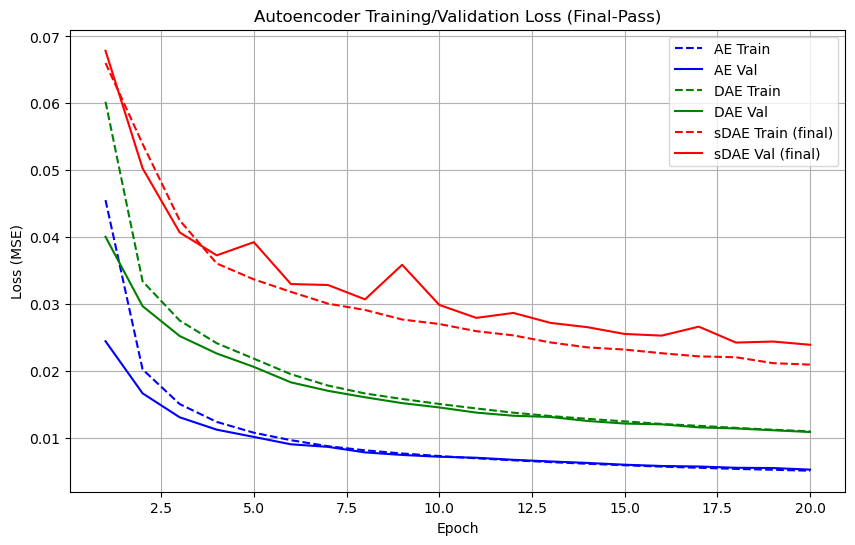

In [6]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
# from .DenoisingAutoencoder import DAE
# from .performance import evaluate, plot_loss_curves, plot_refeed_curves
# from .data_processing import add_noise
# from .stacking_utils import  stacked_dae_loss
import random
# ----------------------------
# Data
# ----------------------------
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=0, pin_memory=True)


history = {
    "AE": {"train": [], "val": []},
    "DAE": {"train": [], "val": []},
    "sDAE": {"train": [], "val_final": [], "val_multi": []}
}


class DAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 784), nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# ----------------------------
# Setup 3 models
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Stacked denoising AE (SDAE): trained with k>1 re-feeds on noisy inputs
sdae = DAE().to(device)

# 2) Single-pass denoising AE (DAE): trained 1 pass on noisy inputs
dae  = DAE().to(device)

# 3) Plain AE: trained 1 pass on clean inputs
ae   = DAE().to(device)

num_epochs = 20
lr = 1e-3
criterion = nn.MSELoss()
opt_ae   = torch.optim.Adam(ae.parameters(), lr=lr)
opt_dae  = torch.optim.Adam(dae.parameters(), lr=lr)
opt_sdae = torch.optim.Adam(sdae.parameters(), lr=lr)

# ----------------------------
# Training loop
# ----------------------------
for epoch in range(1, num_epochs + 1):
    ae.train()
    total_loss, count = 0.0, 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        opt_ae.zero_grad()

        #Forward pass (clean -> clean, 1 feed)
        recon = ae(imgs)
        loss = criterion(recon, imgs)

        #Backwards + update
        loss.backward()
        opt_ae.step()

        # Accumulate training loss
        bsz = imgs.size(0)
        total_loss += loss.item() * bsz
        count += bsz
    
    #Average training loss
    train_loss = total_loss / max(count, 1)

    #Evaluate on test set (clean -> clean)
    val_loss = evaluate(ae, test_loader, device=device, criterion=criterion)
    history["AE"]["train"].append(train_loss)
    history["AE"]["val"].append(val_loss)

    print(f"Epoch [{epoch:03d}/{num_epochs}] "
          f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# -------------------------------------
# Non-stacked DAE Training Loop
# --------------------------------------

for epoch in range(1, num_epochs + 1):
    dae.train()
    total_loss, count = 0.0, 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        noisy_imgs = add_noise(imgs, noise_factor=0.81)

        opt_dae.zero_grad()
        recon = dae(noisy_imgs)
        loss = criterion(recon, imgs)
        loss.backward()
        opt_dae.step()

        bsz = imgs.size(0)
        total_loss += loss.item() * bsz
        count += bsz

    train_loss = total_loss / max(count, 1)

    # use general evaluate (denoising=True, re_feeds=1, stacked=False)
    val_loss = evaluate(dae, test_loader,
                        denoising=True,
                        re_feeds=1,
                        stacked=False,
                        device=device,
                        criterion=criterion)
    history["DAE"]["train"].append(train_loss)
    history["DAE"]["val"].append(val_loss)

    print(f"[DAE] Epoch [{epoch:03d}/{num_epochs}] "
          f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# -------------------------------------
# Stacked DAE Training Loop
# --------------------------------------
k_max = 5
for epoch in range(1, num_epochs + 1):
    sdae.train()
    total_final_loss, count = 0.0, 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        noisy_imgs = add_noise(imgs, noise_factor=0.81)

        k_refeeds = random.randint(1, k_max)

        opt_sdae.zero_grad()
        loss, final_out = stacked_dae_loss(sdae, noisy_imgs, imgs, k=k_refeeds)
        loss.backward()
        opt_sdae.step()

        # log *final-pass* train loss for comparability
        final_loss = torch.mean((final_out - imgs) ** 2).item()
        bsz = imgs.size(0)
        total_final_loss += final_loss * bsz
        count += bsz

    train_loss_final = total_final_loss / max(count, 1)

    # Validation: log both final and multi-step
    val_loss_final = evaluate(sdae, test_loader,
                              denoising=True,
                              re_feeds=k_max,
                              stacked=True,
                              multi_step=False,
                              device=device,
                              criterion=criterion)

    val_loss_multi = evaluate(sdae, test_loader,
                              denoising=True,
                              re_feeds=k_max,
                              stacked=True,
                              multi_step=True,
                              device=device,
                              criterion=criterion)

    history["sDAE"]["train"].append(train_loss_final)   # comparable to AE/DAE
    history["sDAE"]["val_final"].append(val_loss_final) # comparable metric
    history["sDAE"]["val_multi"].append(val_loss_multi) # diagnostic

    print(f"[Stacked DAE] Epoch [{epoch:03d}/{num_epochs}] "
          f"Train Final: {train_loss_final:.6f} | "
          f"Val Final: {val_loss_final:.6f} | Val Multi: {val_loss_multi:.6f}")

plot_loss_curves(history, num_epochs, show_sdae_multi=True)


# Declaring models
models = {"AE": ae, "DAE": dae, "sDAE": sdae}
# plot_refeed_curves(models, test_loader, device, max_refeeds=150)


# def jvp(f: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
#     """
#     Compute J_f(x) @ v (same shape as x) using autograd.
#     x, v have shape (1, D). Returns (1, D).
#     """
#     x = x.detach().requires_grad_(True)
#     y = f(x)
#     assert y.shape == x.shape, "f must be R^D -> R^D (pointwise denoiser)."
#     dot = (y * v).sum()
#     (grad_x,) = torch.autograd.grad(dot, x, retain_graph=True, create_graph=False)
#     return grad_x


# def vjp(f: Callable[[torch.Tensor], torch.Tensor], x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
#     """
#     Compute J_f(x)^T @ u (same shape as x) using autograd.
#     x, u have shape (1, D). Returns (1, D).
#     """
#     x = x.detach().requires_grad_(True)
#     y = f(x)
#     (grad_x,) = torch.autograd.grad(outputs=y, inputs=x, grad_outputs=u, retain_graph=True, create_graph=False)
#     return grad_x


# def spectral_norm_of_jacobian(
#     f: Callable[[torch.Tensor], torch.Tensor],
#     x_star: torch.Tensor,
#     iters: int = 50,
#     device: str = "cpu",
# ) -> float:
#     """
#     Estimate ||J_f(x*)||_2 (largest singular value) via power iteration on J^T J, without
#     materializing J. If < 1, f is locally a contraction at x* (sufficient condition).
#     """
#     with torch.no_grad():
#         x = x_star.view(1, -1).to(device)

#     u = torch.randn_like(x)
#     u = u / (u.norm() + 1e-12)

#     for _ in range(iters):
#         # v = (J^T J) u  ≈  J^T (J u)
#         w = jvp(f, x, u)       # w = J u
#         v = vjp(f, x, w)       # v = J^T w
#         v_norm = v.norm() + 1e-12
#         u = v / v_norm

#     # Rayleigh quotient: ||J u||_2 is the singular value estimate
#     Ju = jvp(f, x, u)
#     return float(Ju.norm().item())

import torch
from dataclasses import dataclass
from typing import Callable, Optional, Tuple

def detect_fixed_point(traj: torch.Tensor, eps: float = 1e-4) -> Optional[int]:
    """
    Detect first t with ||x_{t+1} - x_t||_2 < eps (approx fixed point).
    Returns the index t (0-based), or None if not found.
    """
    diffs = torch.norm(traj[1:] - traj[:-1], dim=1)
    idx = (diffs < eps).nonzero(as_tuple=False)
    return int(idx[0].item()) if idx.numel() > 0 else None


def detect_cycle(
    traj: torch.Tensor,
    max_period: int = 10,
    eps: float = 1e-3,
) -> Tuple[Optional[int], Optional[int]]:
    """
    Search for short limit cycles by checking ||x_t - x_{t-p}||_2 < eps for 2 <= p <= max_period.
    Returns (cycle_start_index, period) or (None, None) if not found.
    """
    T = traj.size(0)
    for p in range(2, max_period + 1):
        for t in range(p, T):
            if torch.norm(traj[t] - traj[t - p]) < eps:
                # Optionally backtrack one period to mark earliest cycle index
                return t - p, p
    return None, None

overall_results = {}   # <-- add this BEFORE the for-loop

# Random trials
def test_random_points(model, trials=10, iters=10):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    """
    fixed_point_count = 0
    cycles_detected = 0

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x = torch.rand((1, 1, 28, 28)).to(device)

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            
            x = x_next.detach()
            
        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])
        

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)
        jvp_of_trial = jvp(trajectory_tensor, x_next)
        vjp_of_trial = vjp(trajectory_tensor, jvp_of_function)
        if fp_idx:
            spectral_norm_of_trial = spectral_norm_of_jacobian(trajectory_tensor, fp_idx)
        else:
            None

        if fp_idx is not None:
            fixed_point_count += 1

        if cyc_start is not None:
            cycles_detected += 1

    
    return fixed_point_count, cycles_detected, jvp_of_trial, vjp_of_trial, spectral_norm_of_trial



===== RANDOM DYNAMICAL TEST RESULTS =====

AE: fixed=0/1000, cycles=0/1000
AE: fixed=[] cycles=[]
AE: mean MSE vs clean image = 0.298323


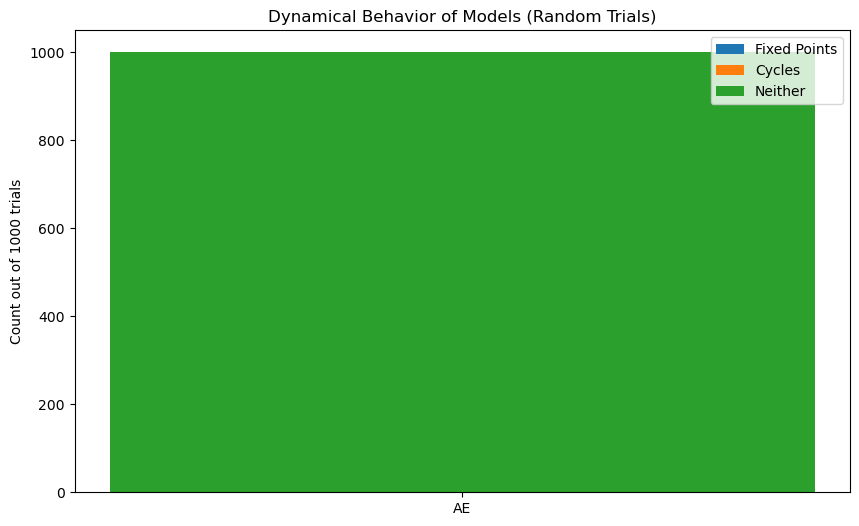

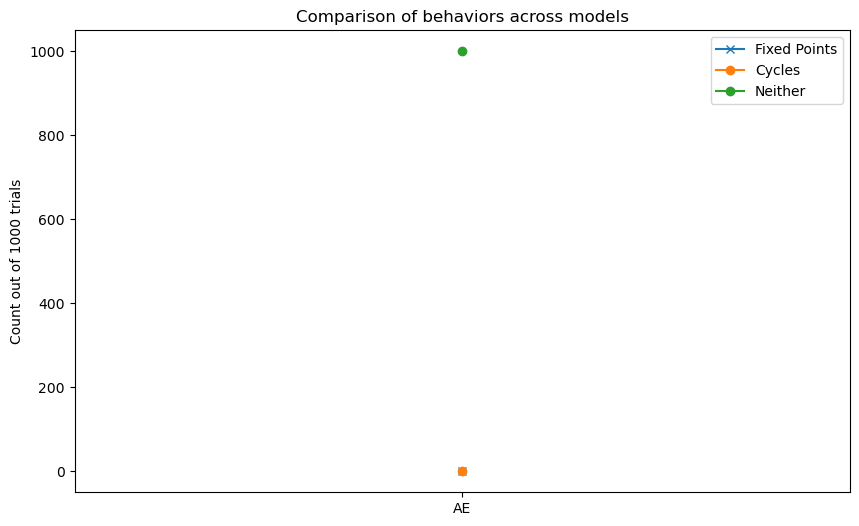


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====

===== MOST FREQUENT CYCLE ATTRACTORS =====

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====

===== VISUALIZING TOP CYCLE ATTRACTORS =====
DAE: fixed=0/1000, cycles=0/1000
DAE: fixed=[] cycles=[]
DAE: mean MSE vs clean image = 0.294534


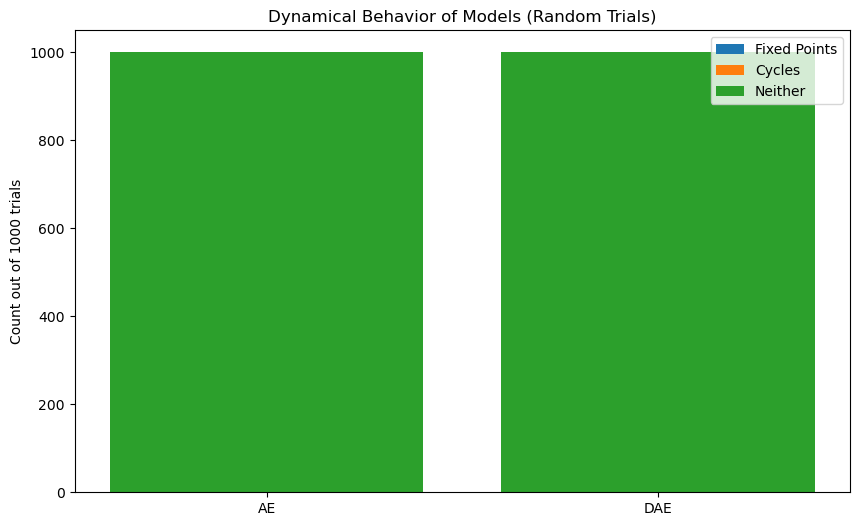

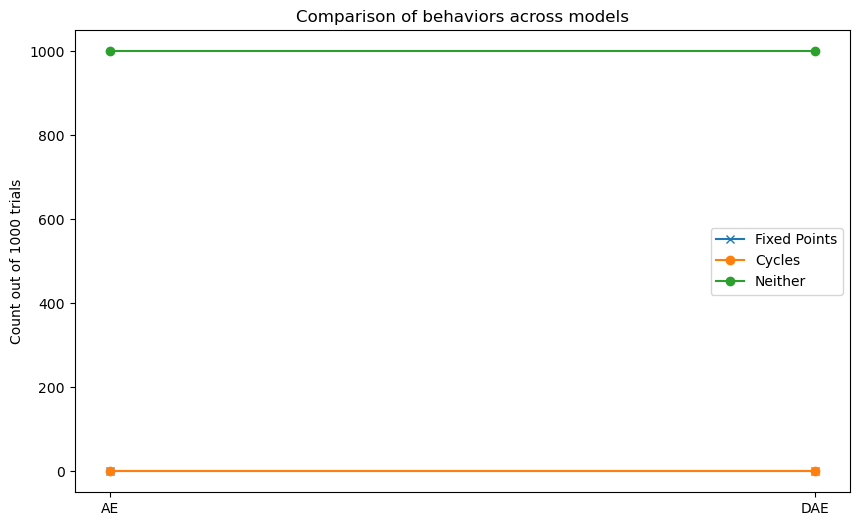


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====

===== MOST FREQUENT CYCLE ATTRACTORS =====

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====

===== VISUALIZING TOP CYCLE ATTRACTORS =====
sDAE: fixed=0/1000, cycles=0/1000
sDAE: fixed=[] cycles=[]
sDAE: mean MSE vs clean image = 0.326053


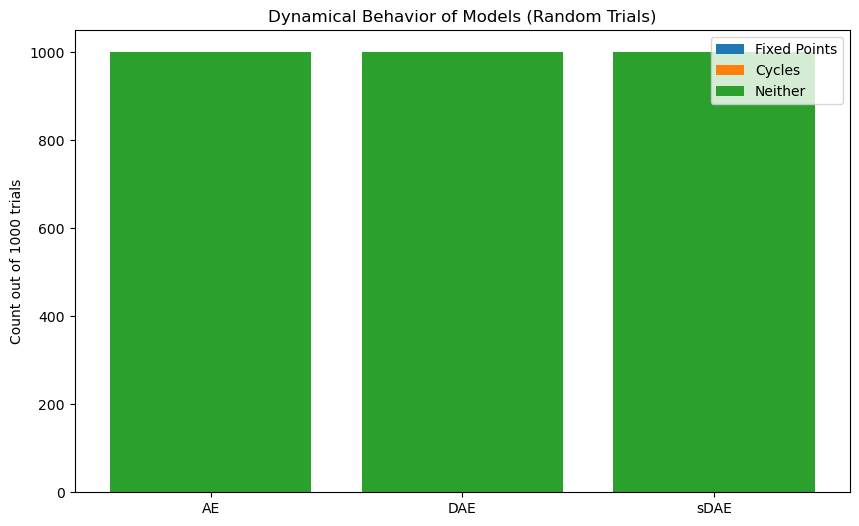

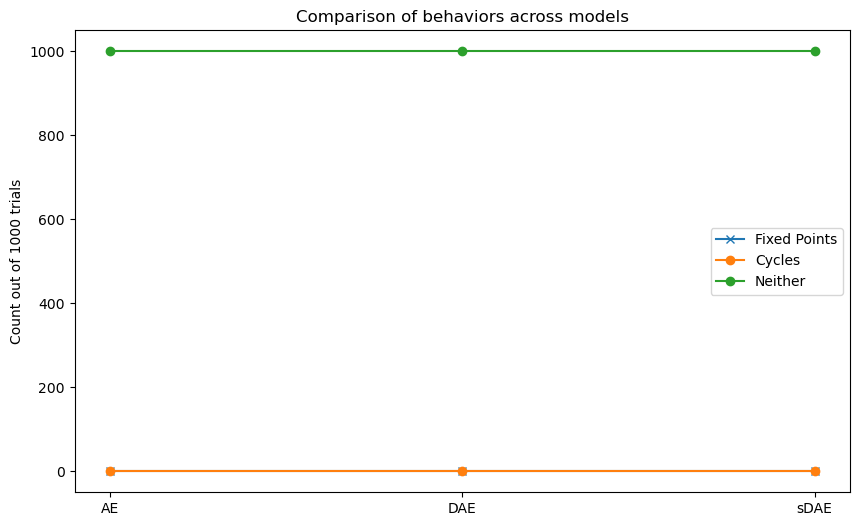


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====

===== MOST FREQUENT CYCLE ATTRACTORS =====

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====

===== VISUALIZING TOP CYCLE ATTRACTORS =====


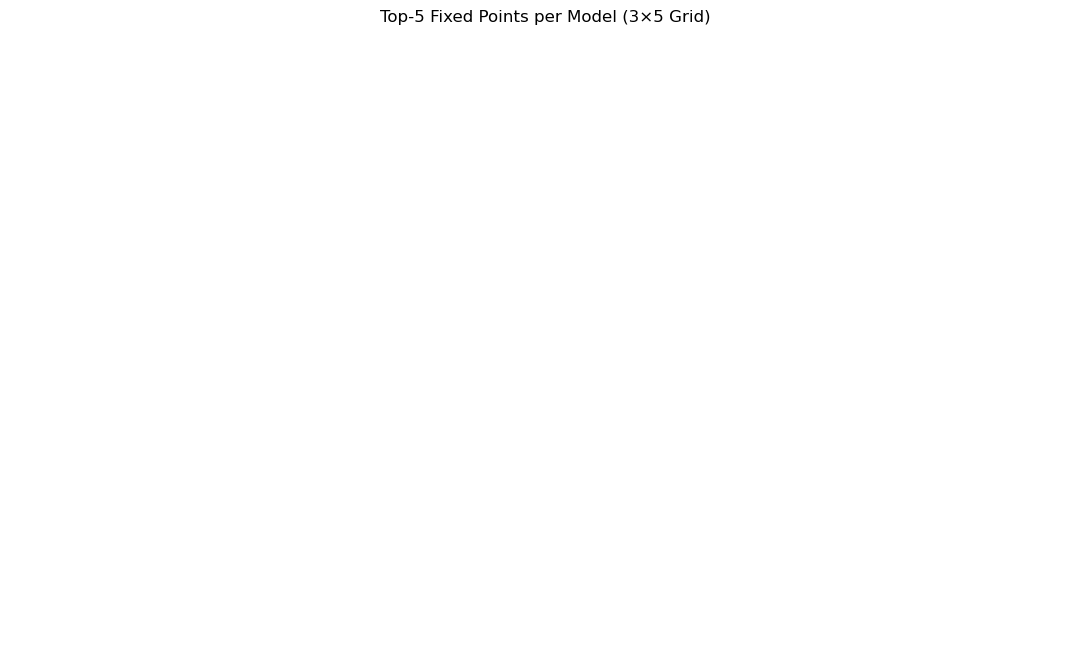


===== AVERAGE MSE COMPARISON ACROSS MODELS =====
AE: mean MSE = 0.298323
DAE: mean MSE = 0.294534
sDAE: mean MSE = 0.326053


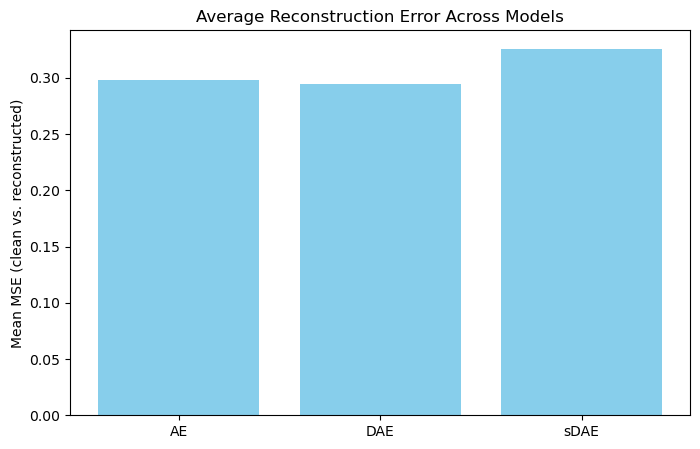

In [7]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []
jvp_values = []
vjp_values = []
spectral_norm_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    # <-- NEW COUNT: track how many trials produced JVP/VJP/SN values
    jvp_count = 0
    vjp_count = 0
    spectral_norm_count = 0

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)  # <-- clean image
        x = add_noise(x_clean, noise_factor=0.81)        # <-- noisy start

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)
        jvp_of_trial = jvp(trajectory_tensor, x_next)
        vjp_of_trial = vjp(trajectory_tensor, jvp_of_function)
        spectral_norm_of_trial = spectral_norm_of_jacobian(trajectory_tensor, fp_idx)

        # <-- NEW COUNT/COLLECT: record availability of JVP/VJP/SN for this trial
        if jvp_of_trial is not None:
            jvp_count += 1
            jvp_values.append(jvp_of_trial)  # <-- NEW COUNT

        if vjp_of_trial is not None:
            vjp_count += 1
            vjp_values.append(vjp_of_trial)  # <-- NEW COUNT

        if spectral_norm_of_trial is not None:
            spectral_norm_count += 1
            spectral_norm_values.append(spectral_norm_of_trial)  # <-- NEW COUNT

        if jvp_of_trial is not None:
            fixed_point_count += 1
            print('JVP in trial:', _)
            # jvp_values append moved above to keep all accounting together

            # NEW: count this fixed-point attractor (quantized for stability)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1   # <-- use model_name instead of name
        
        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            # NEW: count this fixed-point attractor (quantized for stability)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1   # <-- use model_name instead of name

            # <-- NEW DISPLAY: bundle print for this trial alongside fixed point
            print(f"Trial {_:>4} | fixed_idx={fp_idx} | cycle_period={cyc_period if cyc_start is not None else None} | "
                  f"jvp={jvp_of_trial} | vjp={vjp_of_trial} | spectral_norm={spectral_norm_of_trial}")

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            # NEW: count this cycle attractor (use start state as representative)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

            # <-- NEW DISPLAY: bundle print for this trial alongside cycle
            print(f"Trial {_:>4} | fixed_idx={fp_idx} | cycle_period={cyc_period} | "
                  f"jvp={jvp_of_trial} | vjp={vjp_of_trial} | spectral_norm={spectral_norm_of_trial}")

    mean_mse = total_mse / trials   # <-- average MSE over all trials

    # NOTE: return signature unchanged (per your request). Counts are tracked globally via *_values lists,
    # and also locally via jvp_count/vjp_count/spectral_norm_count for on-screen reporting if desired.
    return fixed_point_count, cycles_detected, mean_mse, jvp_of_trial, vjp_of_trial, spectral_norm_of_trial


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse, jvp_of_trial, vjp_of_trial, spectral_norm_of_trial = test_random_points(model, model_name=name, trials=1000, iters=1)
    trials = 1000

    # <-- NEW DISPLAY SUMMARY COUNTS
    jvp_hits = len(jvp_values)
    vjp_hits = len(vjp_values)
    spectral_norm_hits = len(spectral_norm_values)

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),   # keep consistent with trials
        "mean_mse": mean_mse,                         # <-- NEW: store mean MSE
        # <-- NEW: mirror-style accounting for JVP/VJP/SN
        "jvp_count": jvp_hits,
        "vjp_count": vjp_hits,
        "spectral_norm_count": spectral_norm_hits
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    # <-- NEW DISPLAY: aligned “bundle” list print for this model
    print(f"{name}: fixed={fp_values} cycles={cy_values} jvps={jvp_values} vjps={vjp_values} spectral_norms={spectral_norm_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")   # <-- NEW: print MSE

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()




===== RANDOM DYNAMICAL TEST RESULTS =====

AE: fixed=0/1000, cycles=0/1000
AE: fixed=[] cycles=[]
AE: mean MSE vs clean image = 0.312693


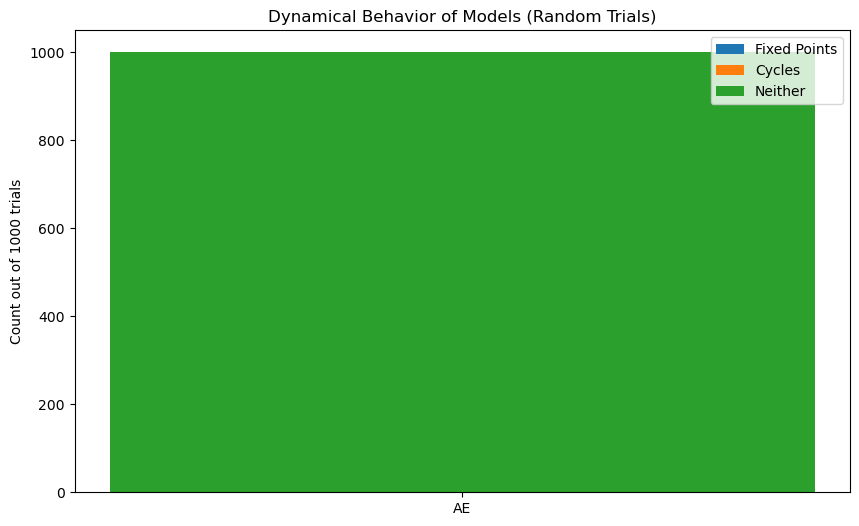

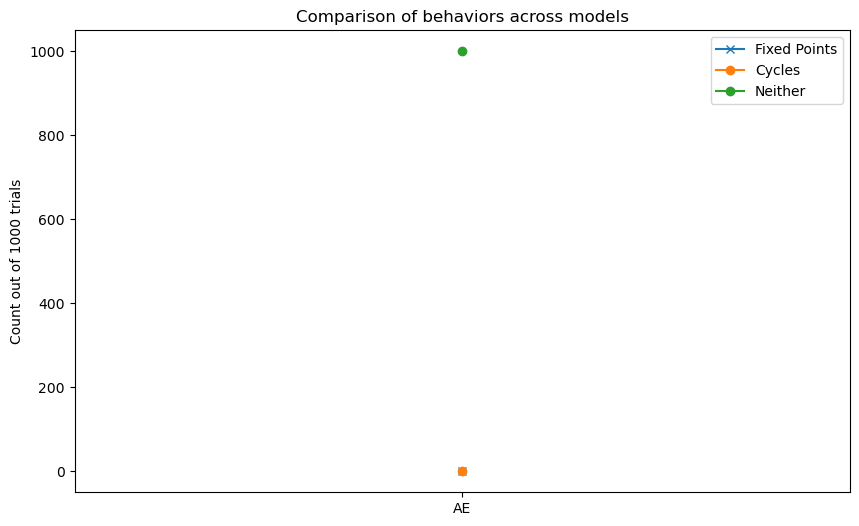


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====

===== MOST FREQUENT CYCLE ATTRACTORS =====

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====

===== VISUALIZING TOP CYCLE ATTRACTORS =====
DAE: fixed=0/1000, cycles=0/1000
DAE: fixed=[] cycles=[]
DAE: mean MSE vs clean image = 0.314818


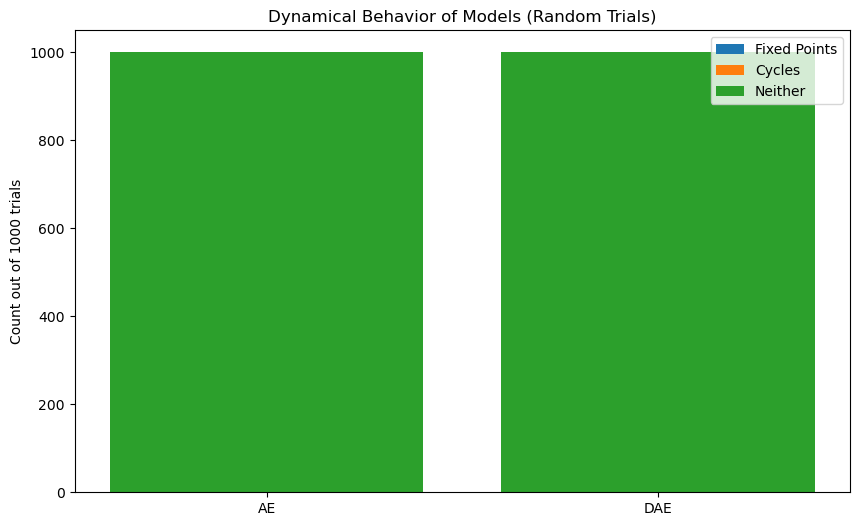

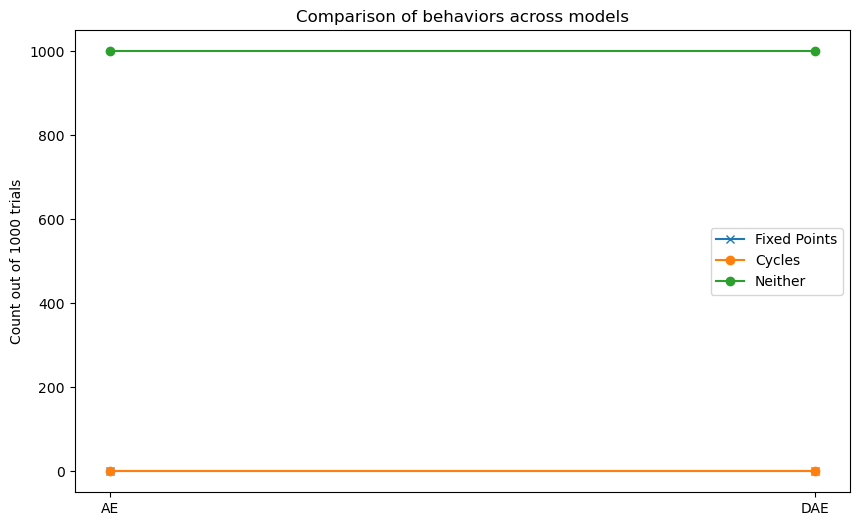


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====

===== MOST FREQUENT CYCLE ATTRACTORS =====

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====

===== VISUALIZING TOP CYCLE ATTRACTORS =====
sDAE: fixed=0/1000, cycles=0/1000
sDAE: fixed=[] cycles=[]
sDAE: mean MSE vs clean image = 0.278594


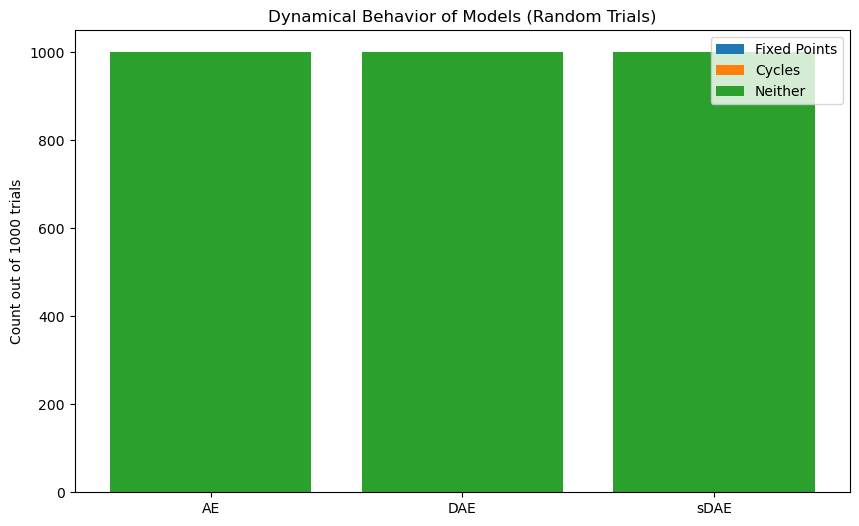

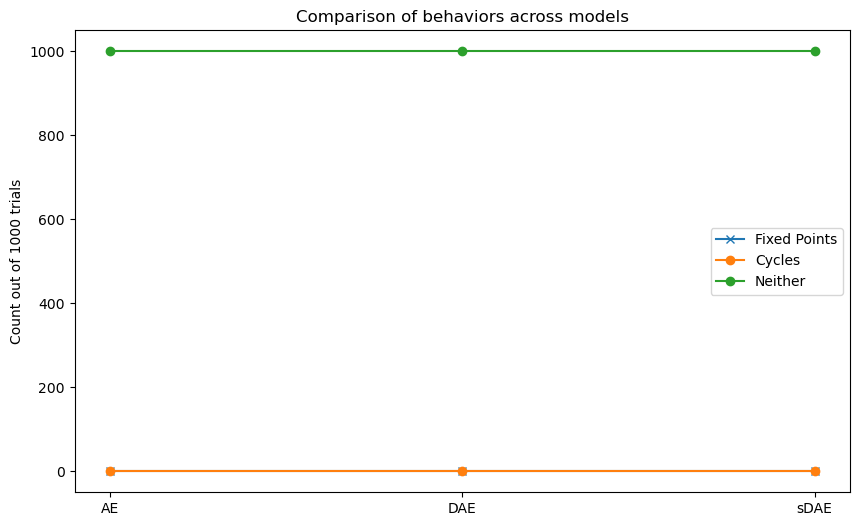


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====

===== MOST FREQUENT CYCLE ATTRACTORS =====

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====

===== VISUALIZING TOP CYCLE ATTRACTORS =====


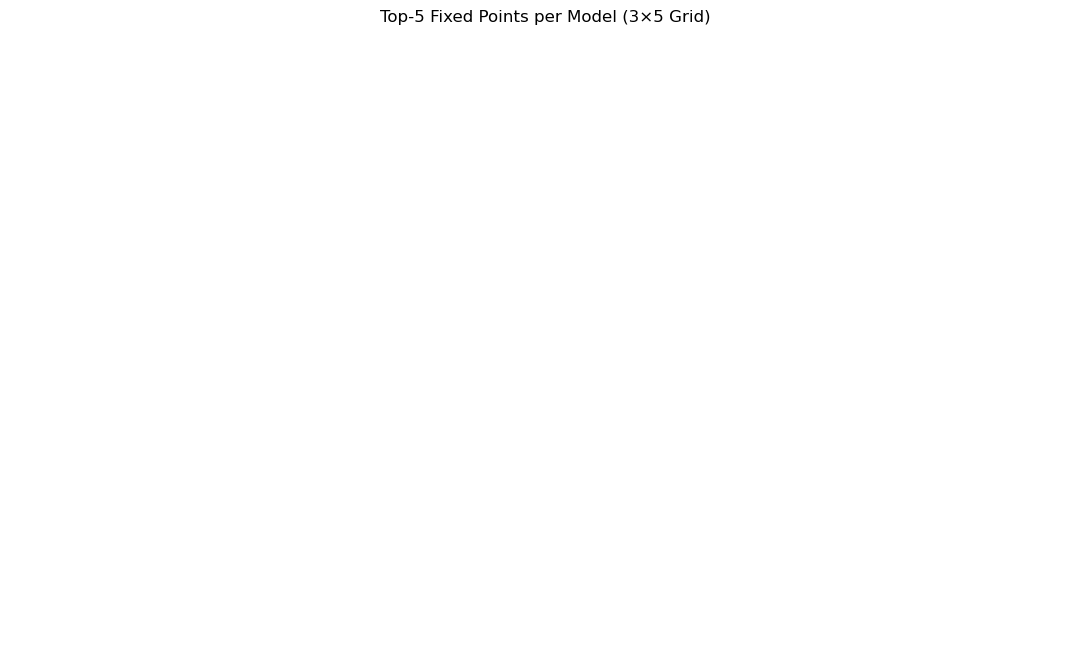


===== AVERAGE MSE COMPARISON ACROSS MODELS =====
AE: mean MSE = 0.312693
DAE: mean MSE = 0.314818
sDAE: mean MSE = 0.278594


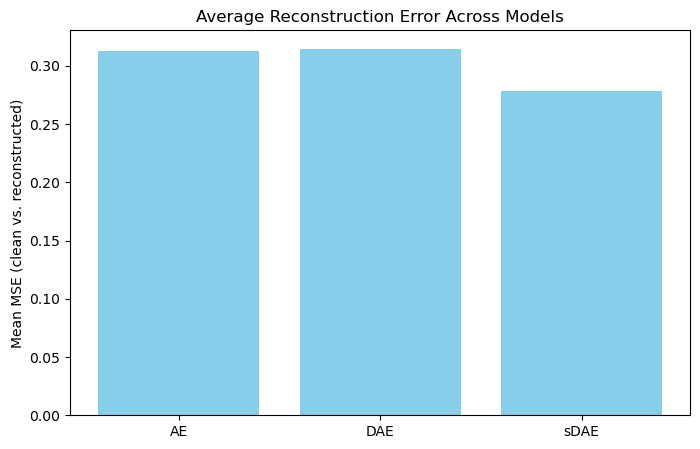

In [8]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)  # <-- clean image
        x = add_noise(x_clean, noise_factor=0.81)        # <-- noisy start

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)

        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            # NEW: count this fixed-point attractor (quantized for stability)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1   # <-- use model_name instead of name
            

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            # NEW: count this cycle attractor (use start state as representative)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

    mean_mse = total_mse / trials   # <-- average MSE over all trials
    return fixed_point_count, cycles_detected, mean_mse


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse = test_random_points(model, model_name=name, trials=1000, iters=10)
    trials = 1000

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),   # keep consistent with trials
        "mean_mse": mean_mse                               # <-- NEW: store mean MSE
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    print(f"{name}: fixed={fp_values} cycles={cy_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")   # <-- NEW: print MSE

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()





===== RANDOM DYNAMICAL TEST RESULTS =====

Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 31
Cycle found in trial: 31
Fixed point found in trial: 37
Cycle found in trial: 37
Fixed point found in trial: 47
Cycle found in trial: 47
Fixed point found in trial: 53
Cycle found in trial: 53
Fixed point found in trial: 61
Cycle found in trial: 61
Fixed point found in trial: 85
Cycle found in trial: 85
Fixed point found in trial: 96
Cycle found in trial: 96
Fixed point found in trial: 104
Cycle found in trial: 104
Fixed point found in trial: 116
Cycle found in trial: 116
Fixed point found in trial: 126
Cycle found in trial: 126
Fixed point found in trial: 136
Cycle found in trial: 136
Fixed point found in trial: 145
Cycle found in trial: 145
Fixed point found in trial: 158
Cycle found in trial: 158
Fixed point found in trial: 160
Cycle found in trial: 160
Fixed point found in trial: 170
Cycle found in trial: 170
Fixed point found in trial: 180
Cycle found 

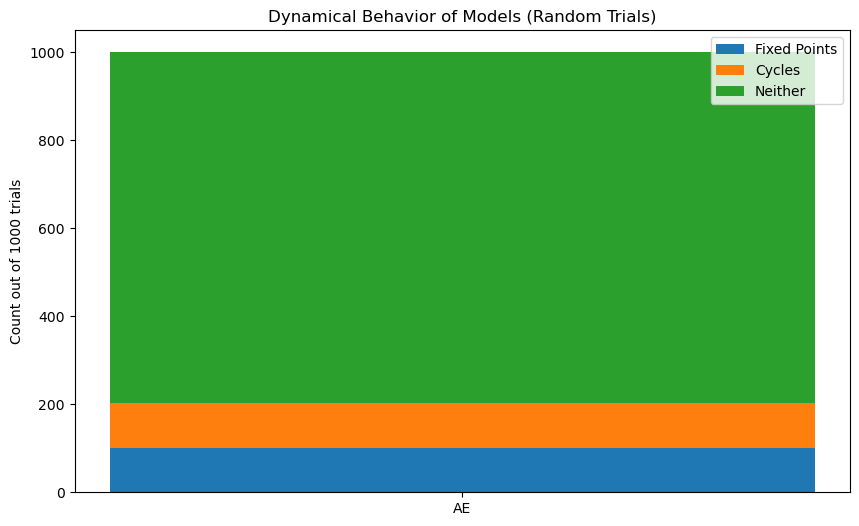

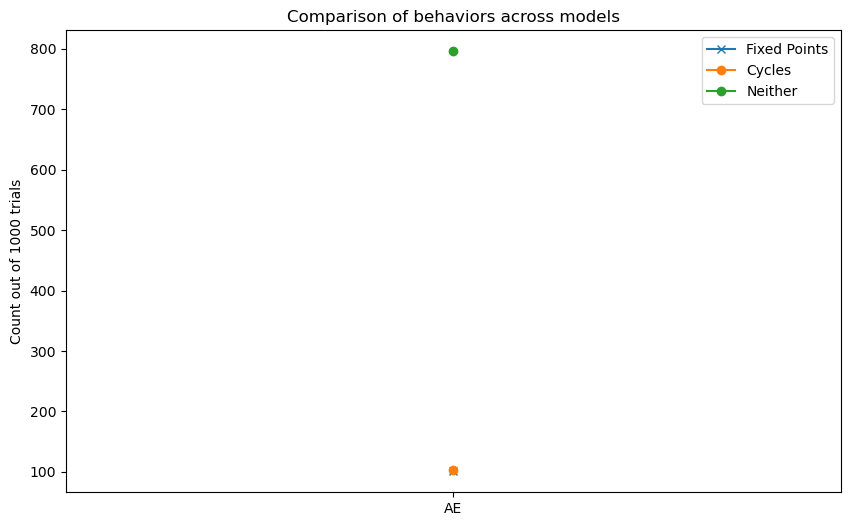


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=71
2. count=12
3. count=6
4. count=6
5. count=2

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=32
2. count=10
3. count=9
4. count=6
5. count=4

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


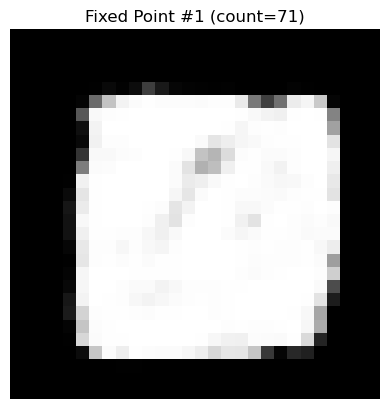

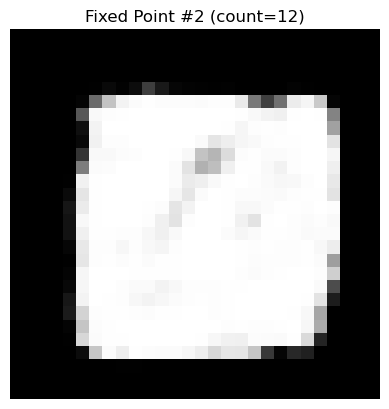

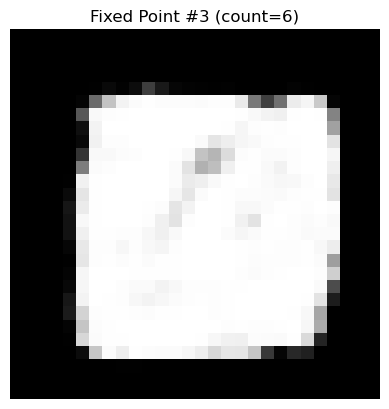


===== VISUALIZING TOP CYCLE ATTRACTORS =====


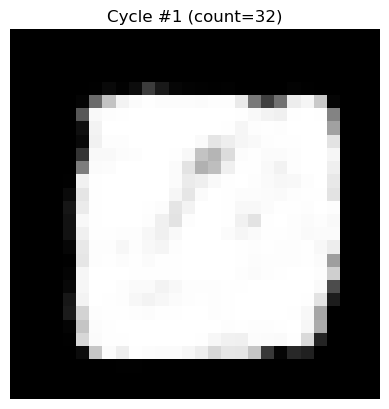

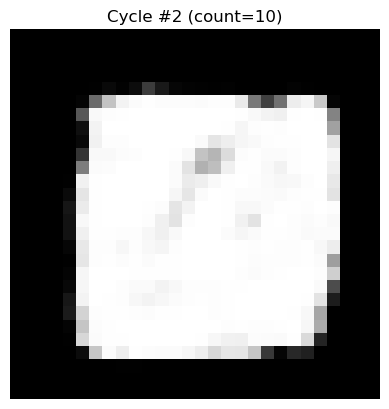

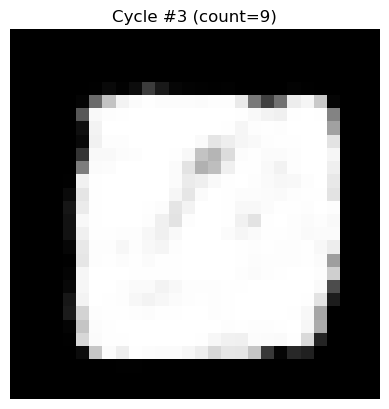

Fixed point found in trial: 63
Cycle found in trial: 63
Fixed point found in trial: 65
Cycle found in trial: 65
Fixed point found in trial: 168
Cycle found in trial: 168
Fixed point found in trial: 318
Cycle found in trial: 318
Fixed point found in trial: 643
Cycle found in trial: 643
Fixed point found in trial: 707
Cycle found in trial: 707
DAE: fixed=6/1000, cycles=6/1000
DAE: fixed=[38, 30, 25, 36, 35, 30, 36, 38, 33, 38, 37, 27, 32, 30, 30, 36, 31, 35, 36, 35, 34, 26, 37, 91, 38, 26, 36, 35, 38, 34, 29, 38, 37, 36, 38, 28, 35, 38, 41, 42, 40, 33, 26, 36, 33, 39, 24, 36, 35, 29, 38, 29, 34, 37, 28, 29, 33, 37, 37, 37, 29, 30, 30, 38, 39, 35, 25, 40, 27, 31, 38, 38, 39, 35, 36, 42, 32, 35, 27, 35, 27, 33, 26, 36, 38, 32, 33, 26, 36, 29, 40, 33, 34, 29, 36, 40, 29, 32, 26, 35, 36, 80, 72, 76, 98, 98, 69] cycles=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

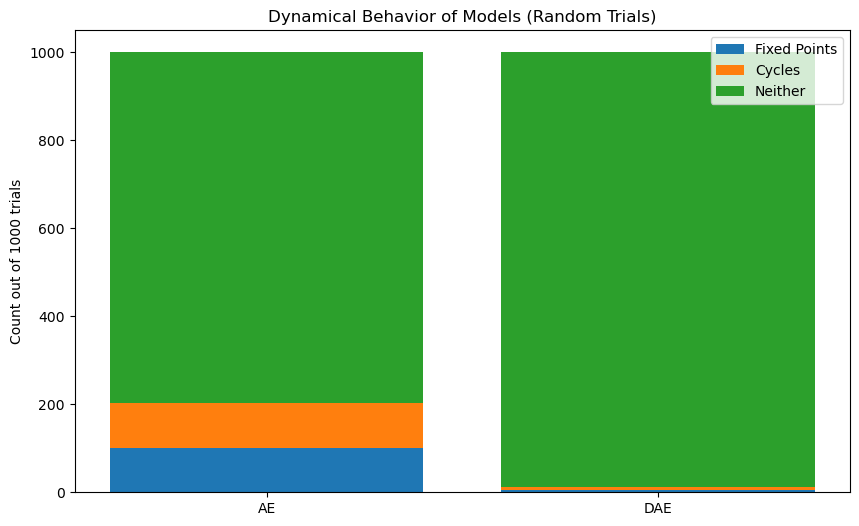

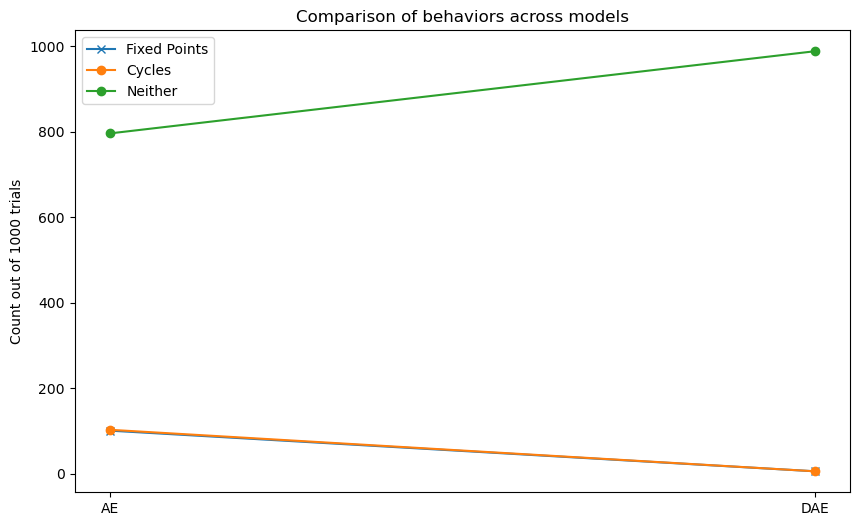


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=71
2. count=12
3. count=6
4. count=6
5. count=3

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=32
2. count=10
3. count=9
4. count=6
5. count=4

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


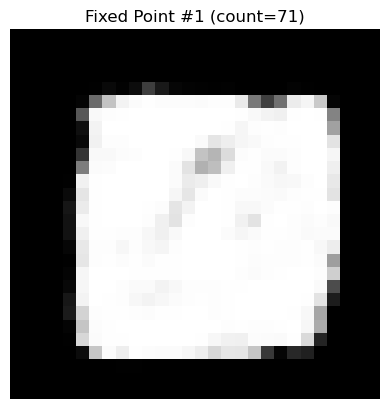

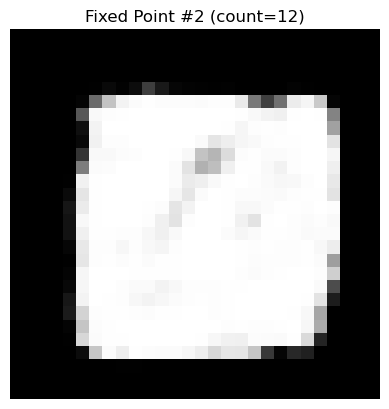

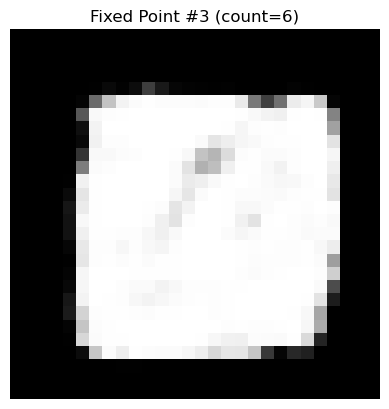


===== VISUALIZING TOP CYCLE ATTRACTORS =====


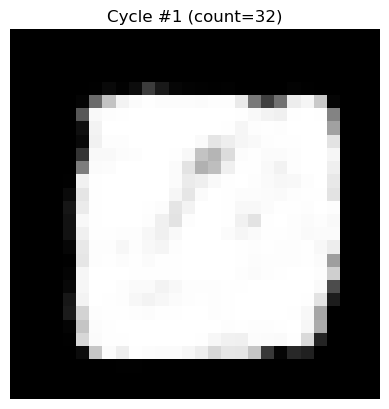

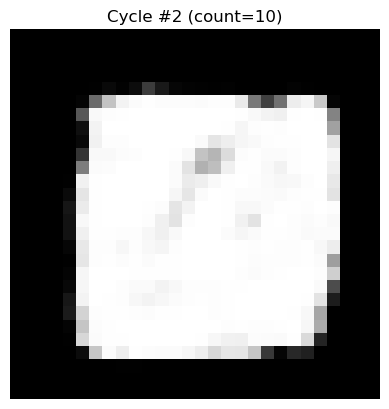

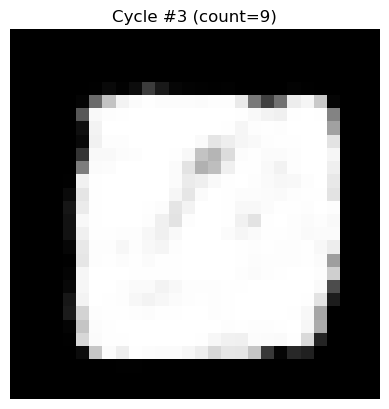

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in trial: 18
Cycle found in trial: 18
Fixed point found in trial: 20
Cycle found in trial: 20
Fixed point found in trial: 21
Cycle found in trial: 21
Fixed point found in trial: 22
Cycle found in trial: 22
Fixed point found in trial: 23
Cycle found in trial: 23
Fixed point found in trial: 24
Cycle found in trial: 24
Fixed point found in trial: 27
Cycle found in trial: 27
Fi

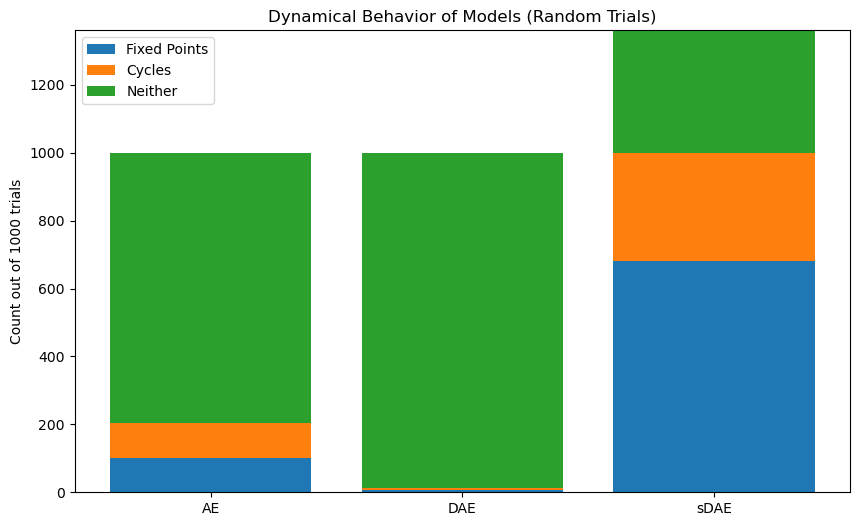

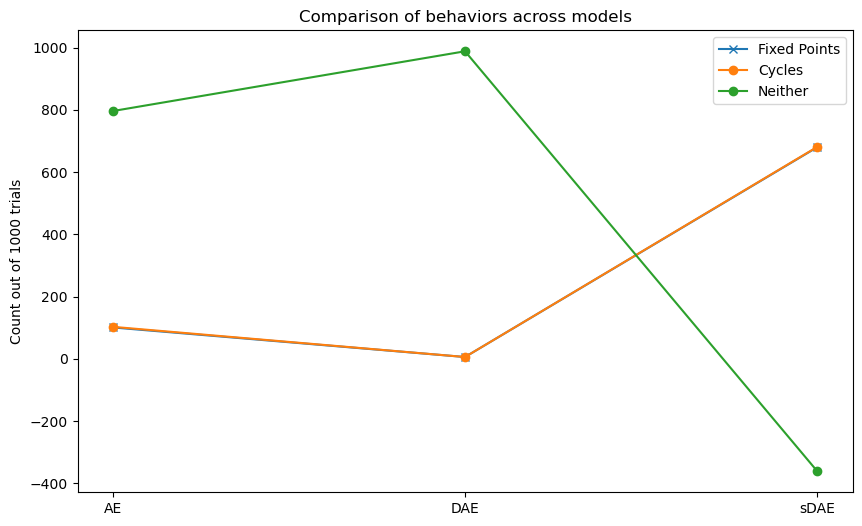


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=309
2. count=72
3. count=71
4. count=58
5. count=32

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=37
2. count=35
3. count=32
4. count=31
5. count=29

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


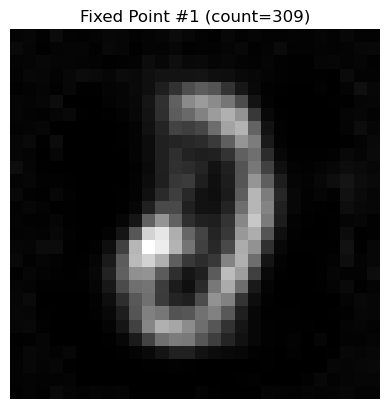

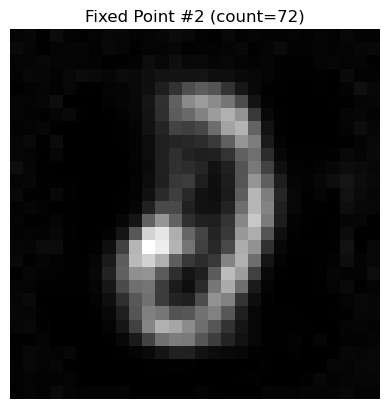

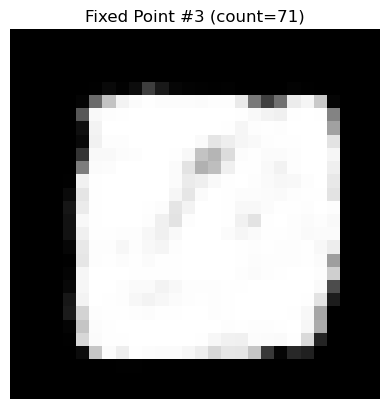


===== VISUALIZING TOP CYCLE ATTRACTORS =====


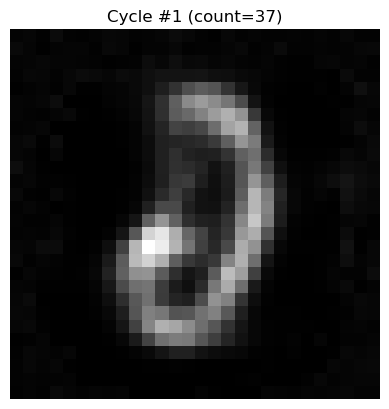

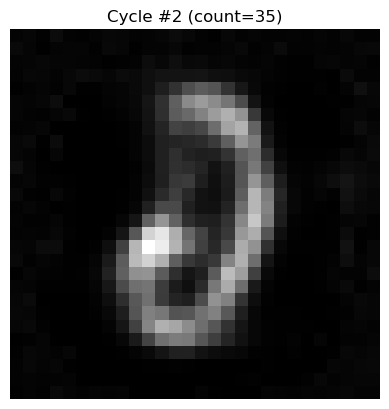

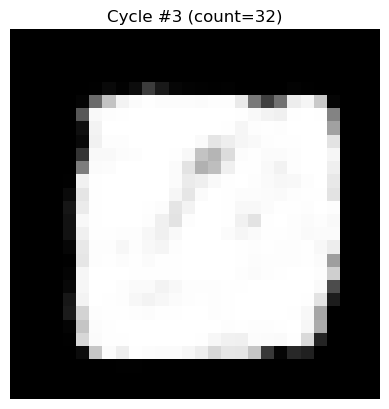

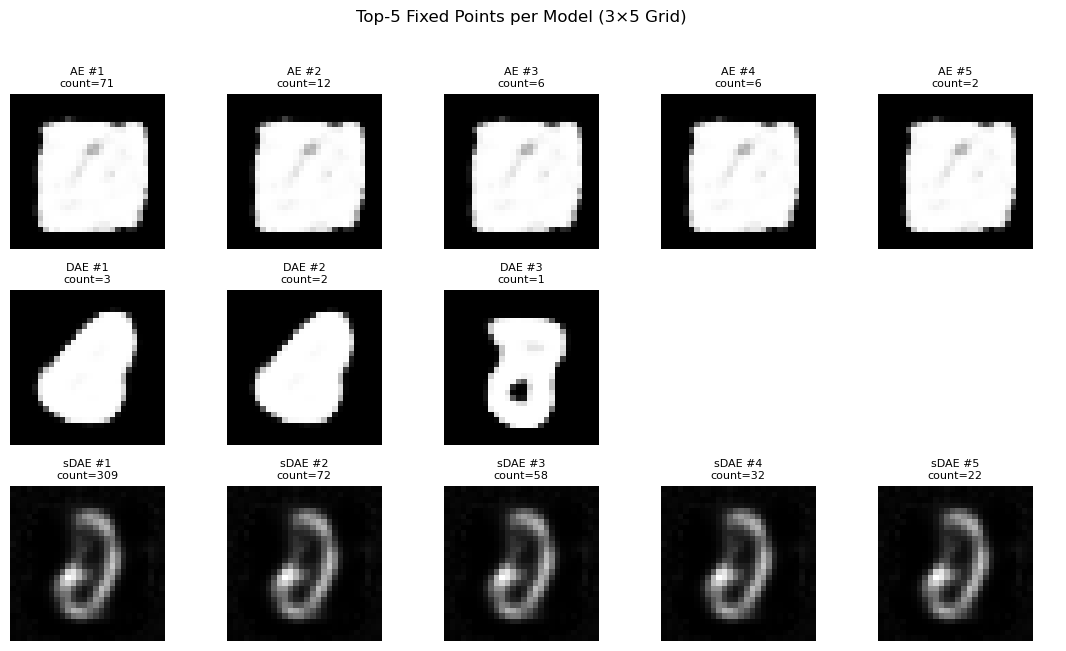


===== AVERAGE MSE COMPARISON ACROSS MODELS =====
AE: mean MSE = 0.307690
DAE: mean MSE = 0.321972
sDAE: mean MSE = 0.279610


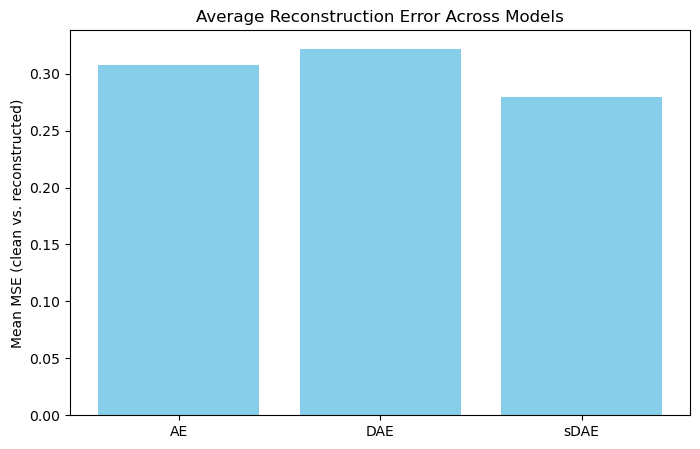

In [9]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)  # <-- clean image
        x = add_noise(x_clean, noise_factor=0.81)        # <-- noisy start

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)

        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            # NEW: count this fixed-point attractor (quantized for stability)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1   # <-- use model_name instead of name
            

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            # NEW: count this cycle attractor (use start state as representative)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

    mean_mse = total_mse / trials   # <-- average MSE over all trials
    return fixed_point_count, cycles_detected, mean_mse


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse = test_random_points(model, model_name=name, trials=1000, iters=100)
    trials = 1000

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),   # keep consistent with trials
        "mean_mse": mean_mse                               # <-- NEW: store mean MSE
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    print(f"{name}: fixed={fp_values} cycles={cy_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")   # <-- NEW: print MSE

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()




===== RANDOM DYNAMICAL TEST RESULTS =====

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in tri

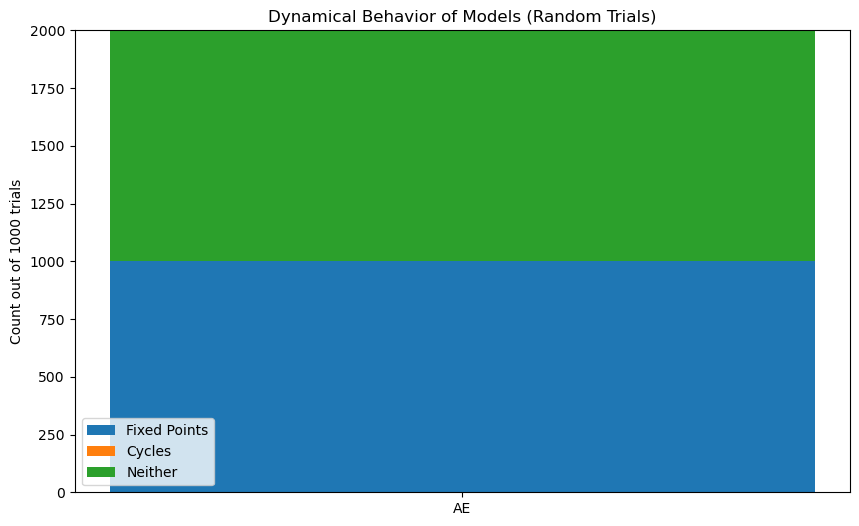

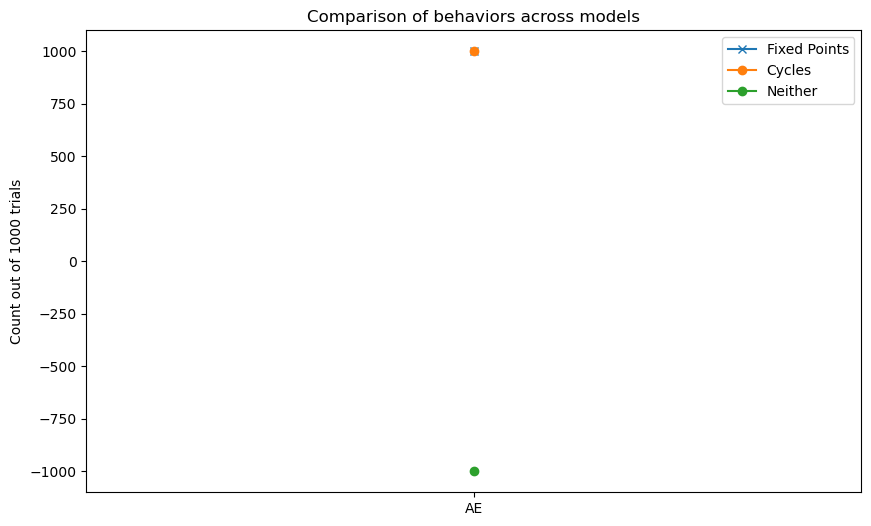


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=630
2. count=227
3. count=57
4. count=35
5. count=17

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=614
2. count=112
3. count=73
4. count=69
5. count=27

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


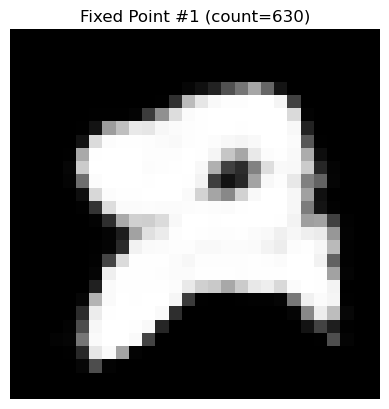

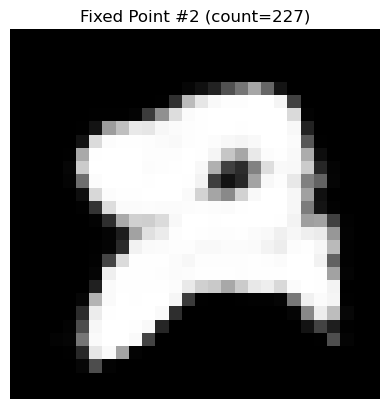

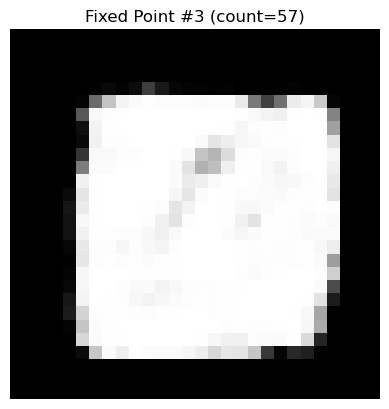


===== VISUALIZING TOP CYCLE ATTRACTORS =====


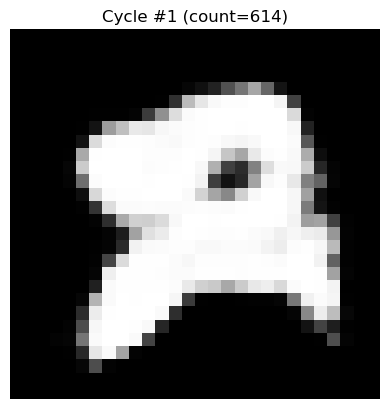

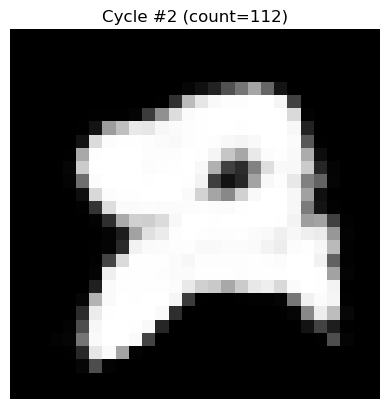

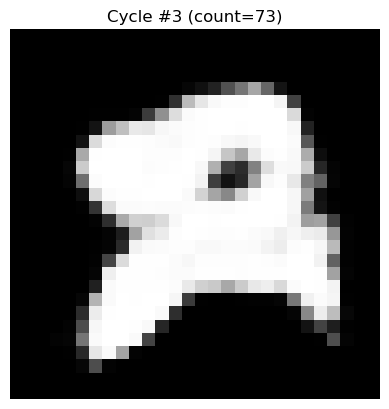

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in trial: 17
Cycle found in trial: 17
Fixed point 

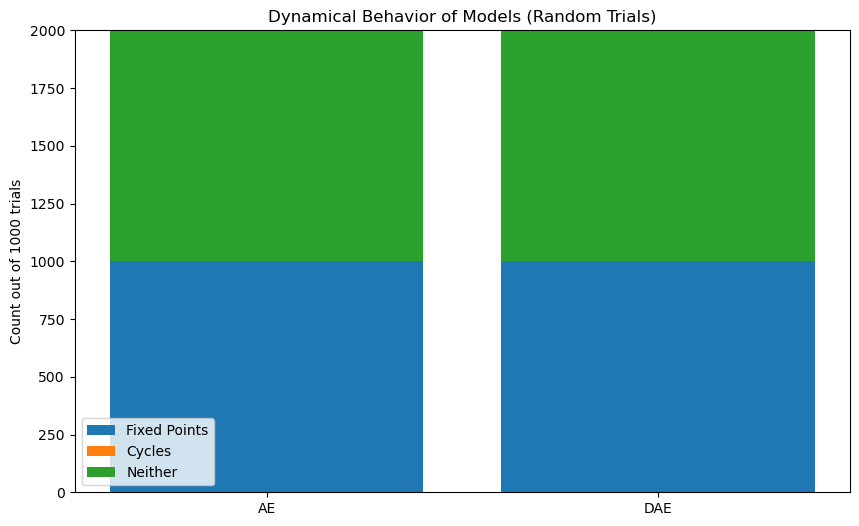

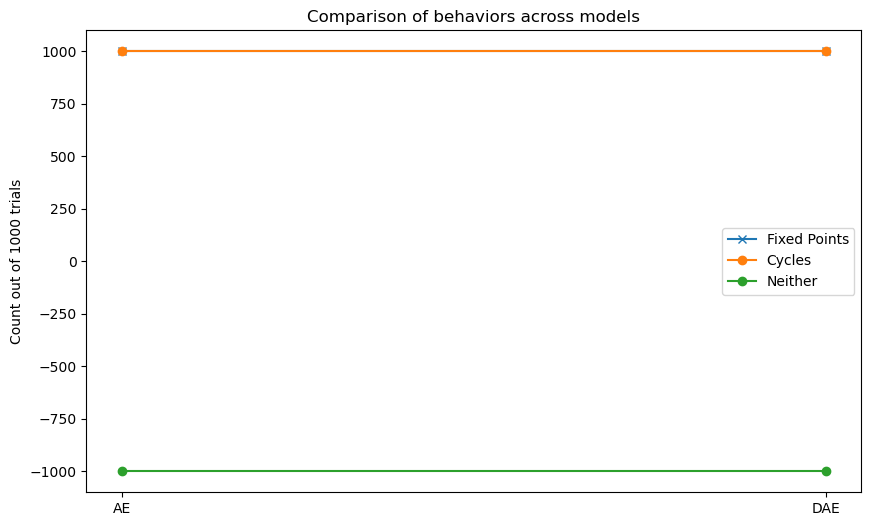


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=984
2. count=630
3. count=227
4. count=57
5. count=35

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=614
2. count=301
3. count=235
4. count=140
5. count=133

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


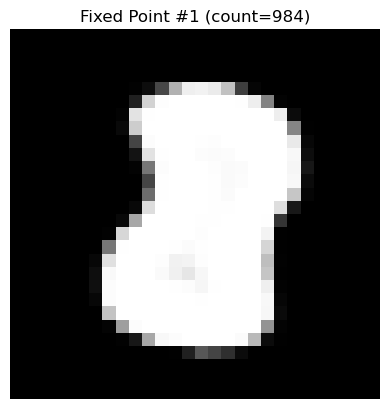

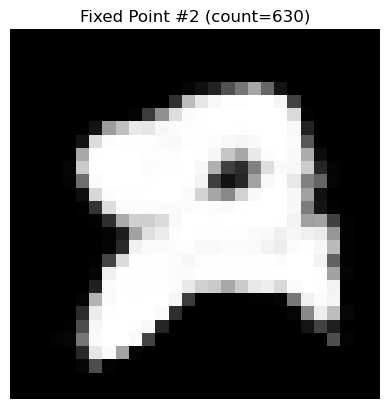

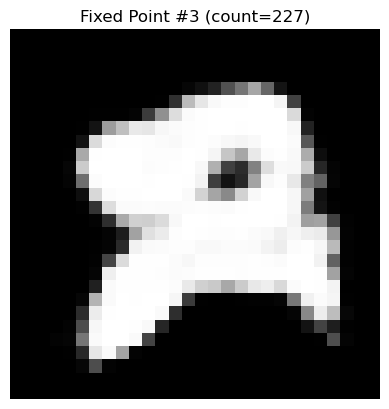


===== VISUALIZING TOP CYCLE ATTRACTORS =====


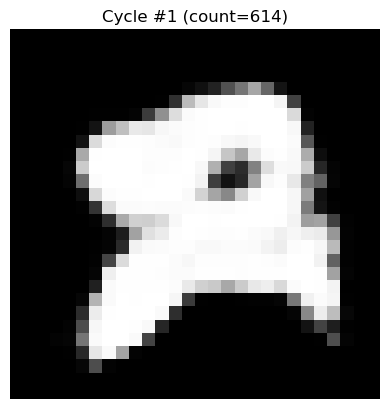

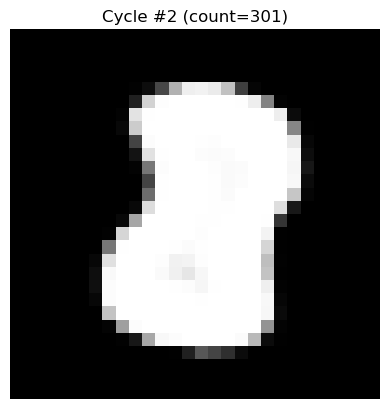

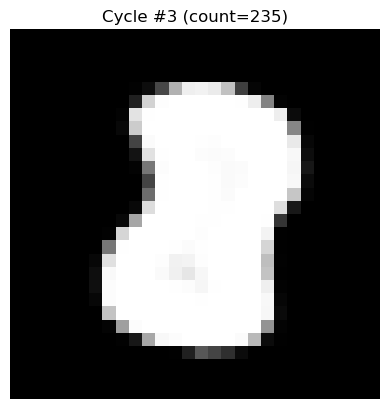

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in trial: 17
Cycle found in trial: 17
Fixed point 

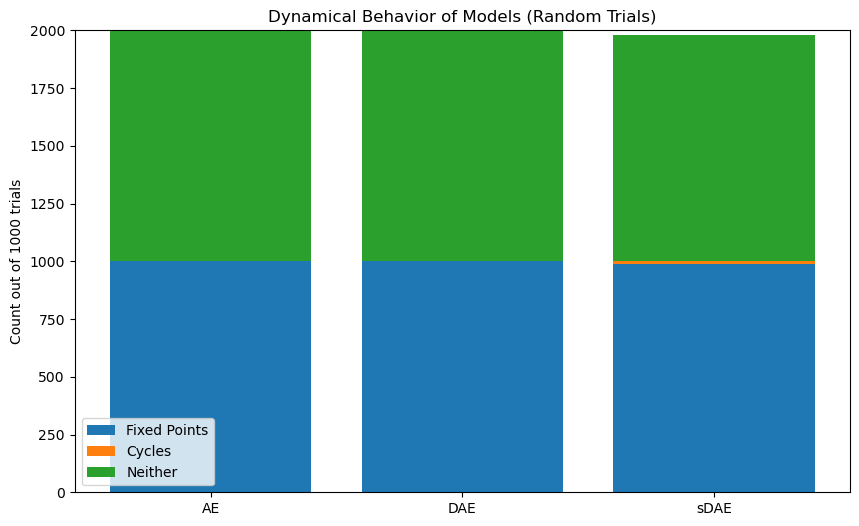

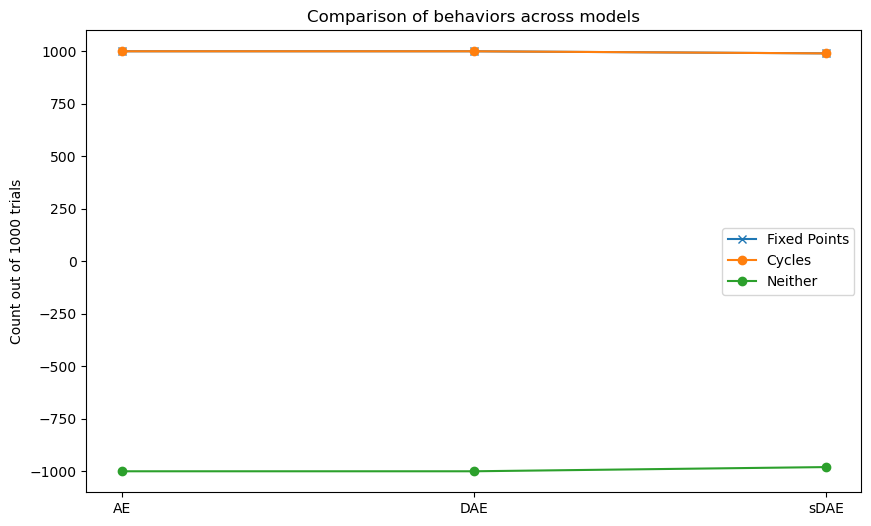


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=984
2. count=630
3. count=308
4. count=227
5. count=64

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=614
2. count=301
3. count=235
4. count=140
5. count=133

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


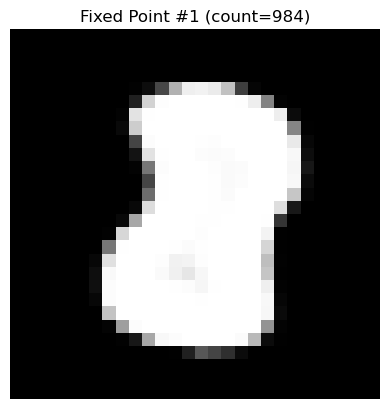

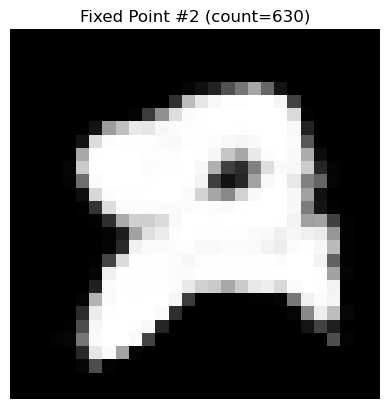

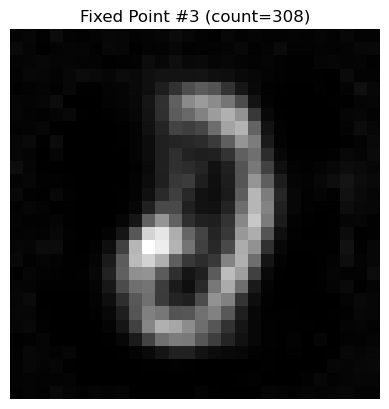


===== VISUALIZING TOP CYCLE ATTRACTORS =====


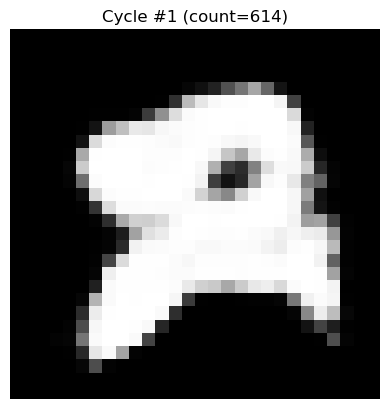

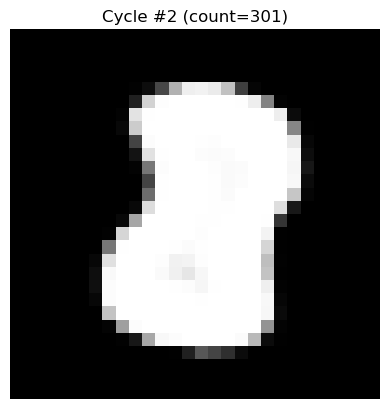

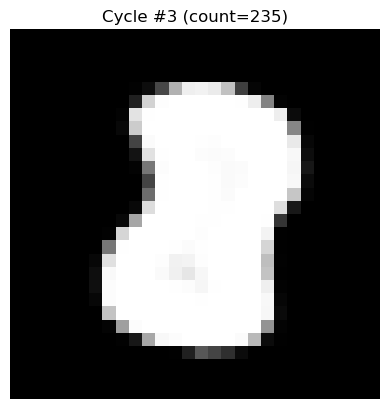

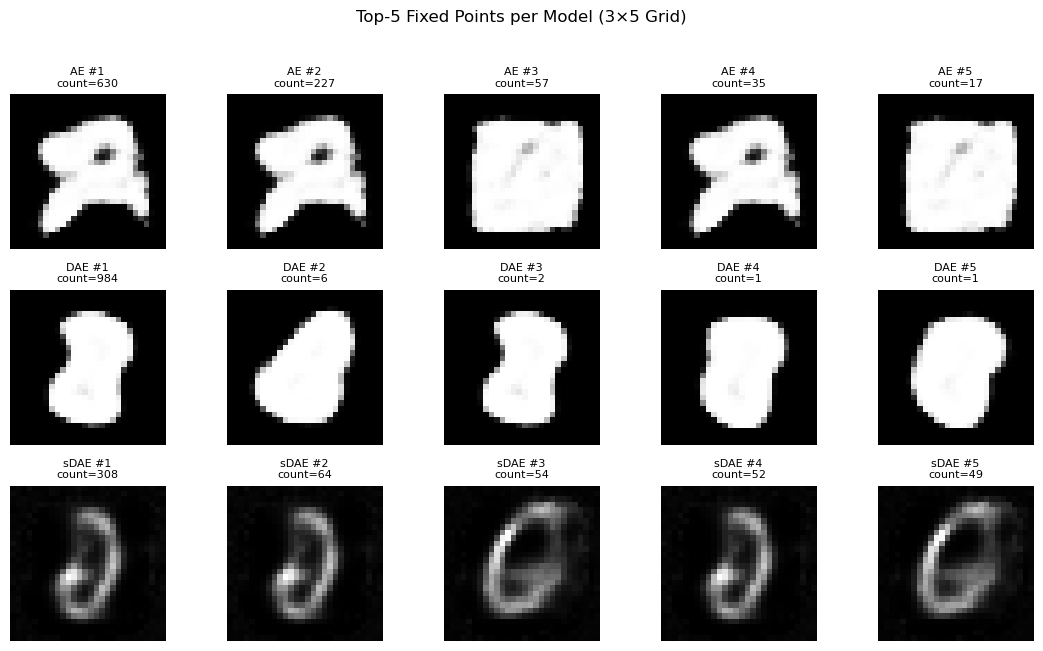


===== AVERAGE MSE COMPARISON ACROSS MODELS =====
AE: mean MSE = 0.307560
DAE: mean MSE = 0.321893
sDAE: mean MSE = 0.281079


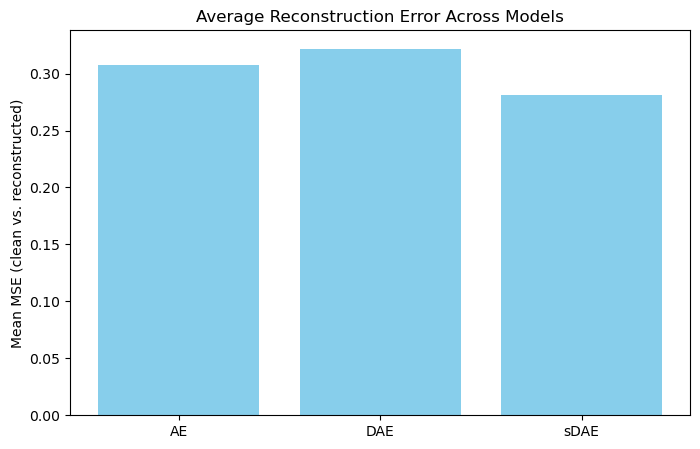

In [10]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)  # <-- clean image
        x = add_noise(x_clean, noise_factor=0.81)        # <-- noisy start

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)

        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            # NEW: count this fixed-point attractor (quantized for stability)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1   # <-- use model_name instead of name
            

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            # NEW: count this cycle attractor (use start state as representative)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

    mean_mse = total_mse / trials   # <-- average MSE over all trials
    return fixed_point_count, cycles_detected, mean_mse


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse = test_random_points(model, model_name=name, trials=1000, iters=1000)
    trials = 1000

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),   # keep consistent with trials
        "mean_mse": mean_mse                               # <-- NEW: store mean MSE
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    print(f"{name}: fixed={fp_values} cycles={cy_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")   # <-- NEW: print MSE

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()




===== RANDOM DYNAMICAL TEST RESULTS =====

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in tri

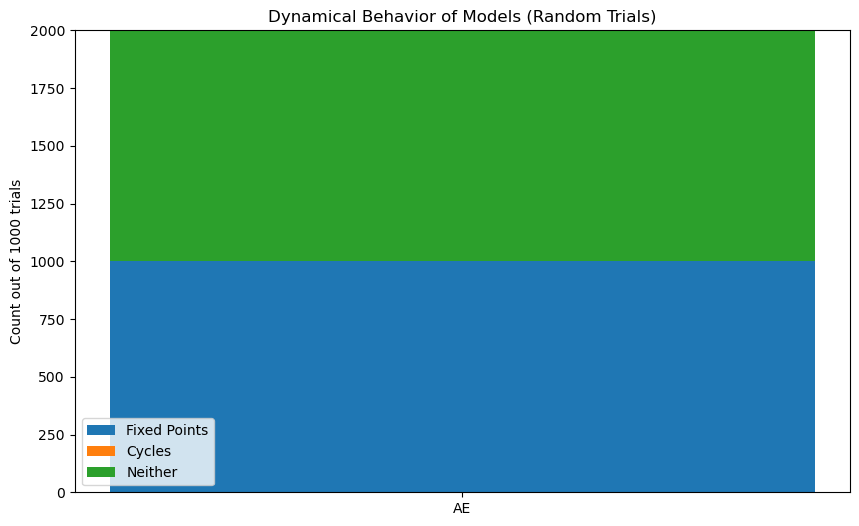

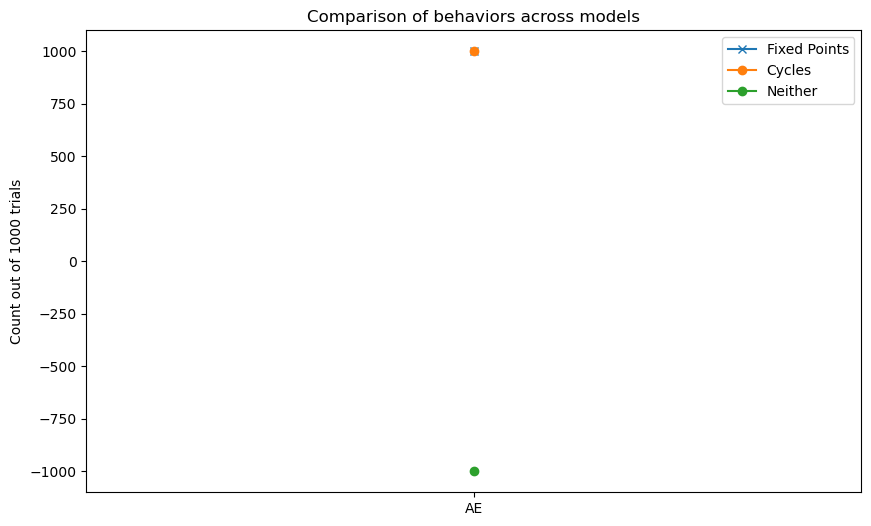


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=619
2. count=226
3. count=63
4. count=50
5. count=14

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=633
2. count=107
3. count=80
4. count=51
5. count=22

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


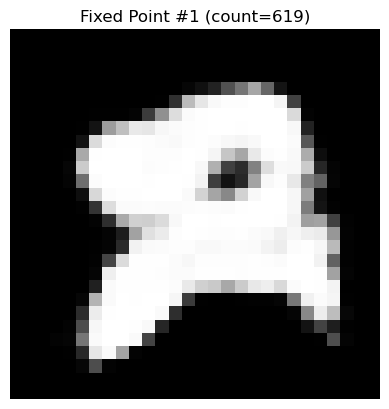

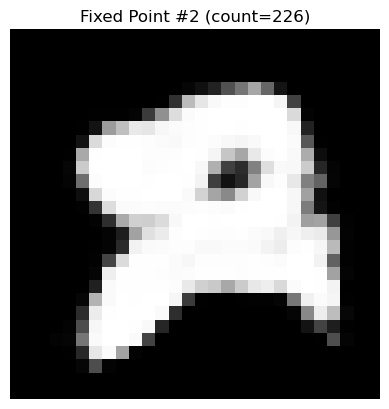

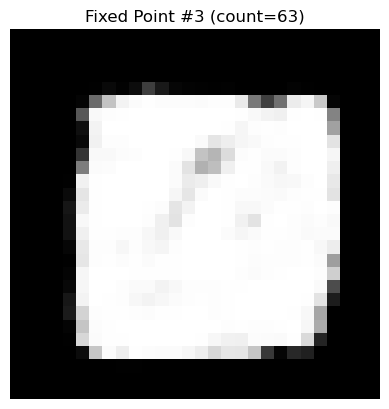


===== VISUALIZING TOP CYCLE ATTRACTORS =====


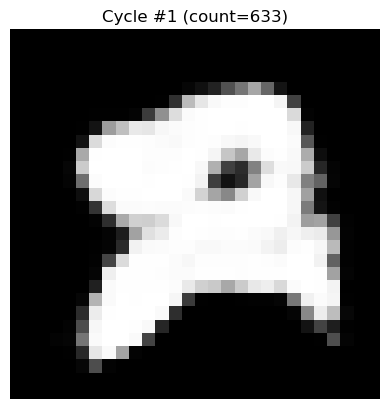

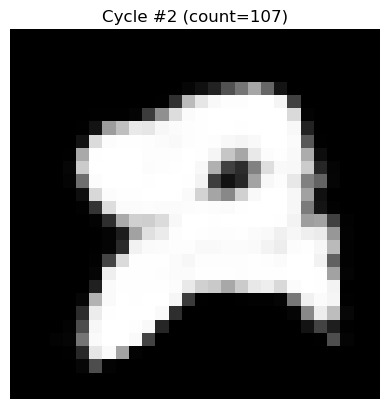

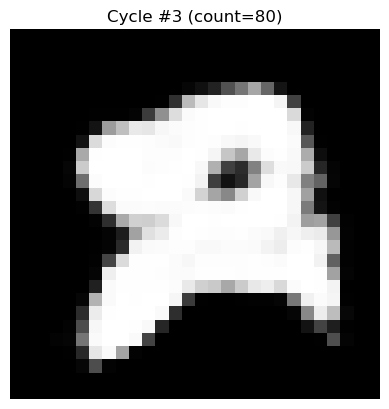

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in trial: 17
Cycle found in trial: 17
Fixed point 

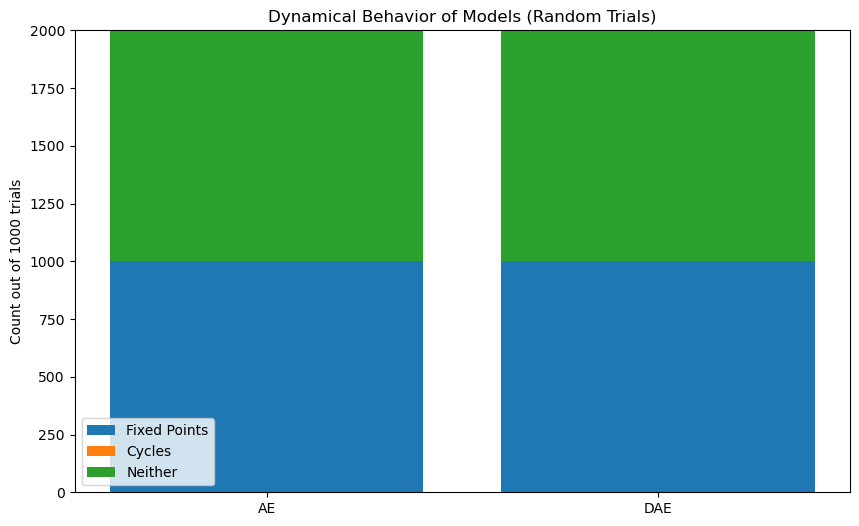

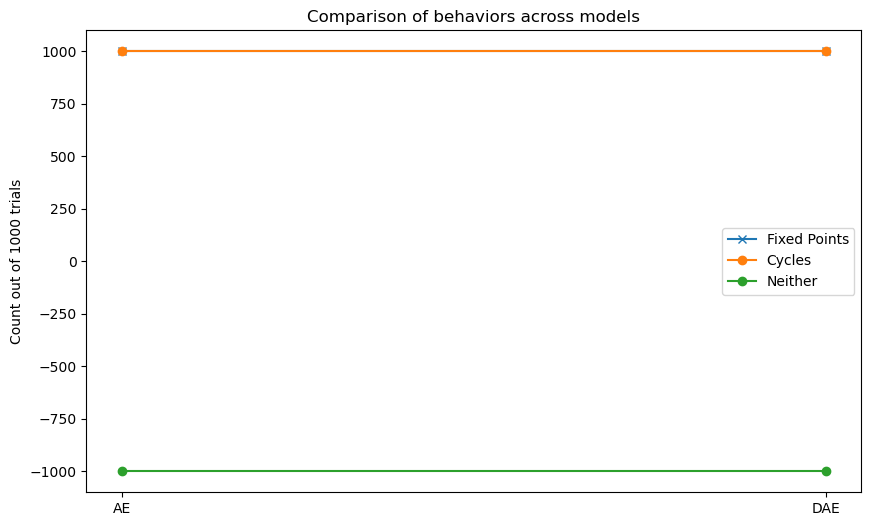


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=987
2. count=619
3. count=226
4. count=63
5. count=50

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=633
2. count=300
3. count=226
4. count=150
5. count=111

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


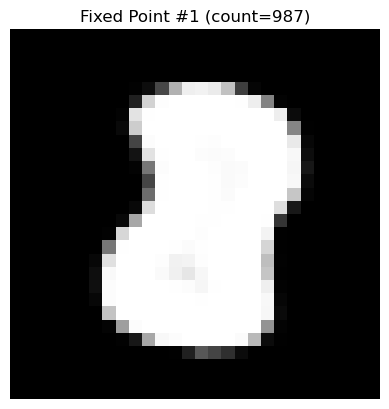

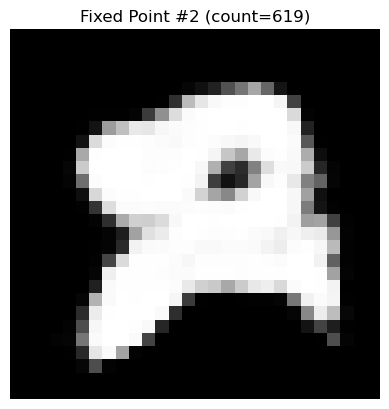

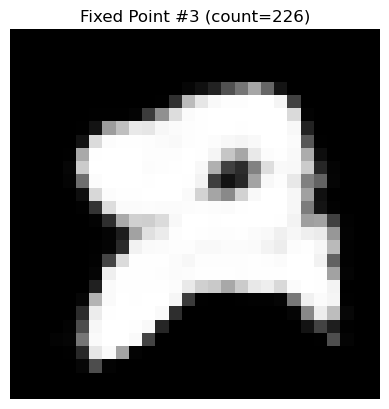


===== VISUALIZING TOP CYCLE ATTRACTORS =====


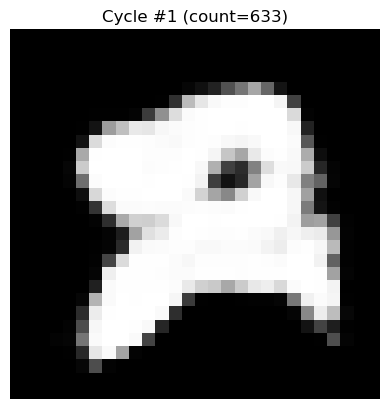

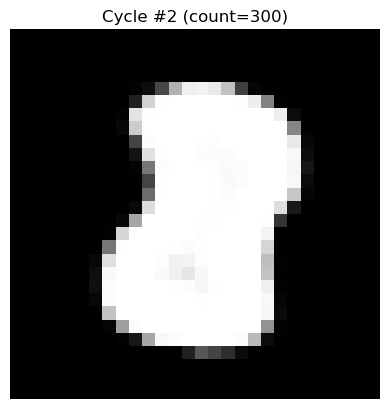

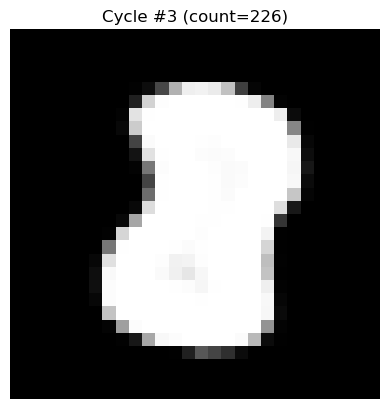

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in trial: 17
Cycle found in trial: 17
Fixed point 

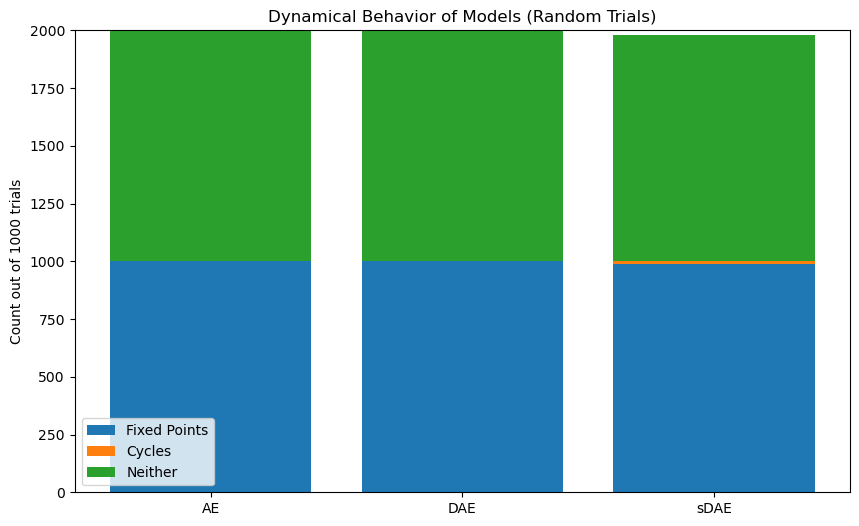

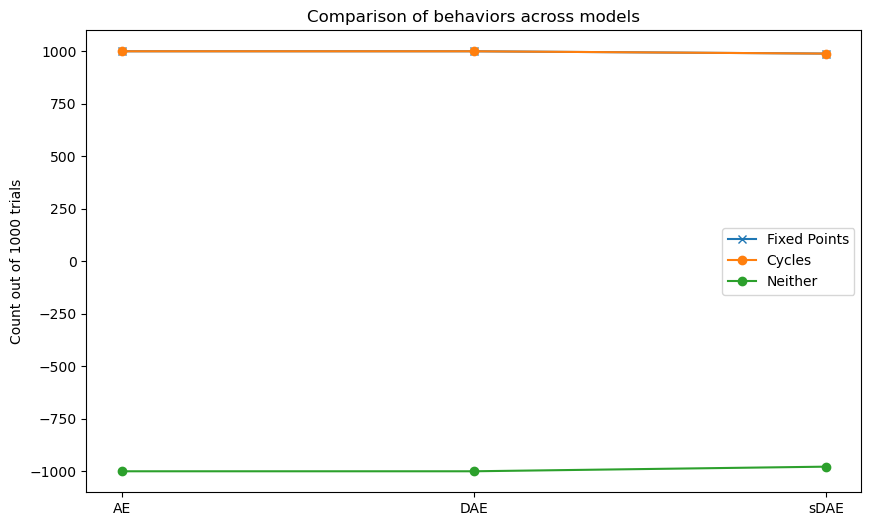


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=987
2. count=619
3. count=320
4. count=226
5. count=73

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=633
2. count=300
3. count=226
4. count=150
5. count=111

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


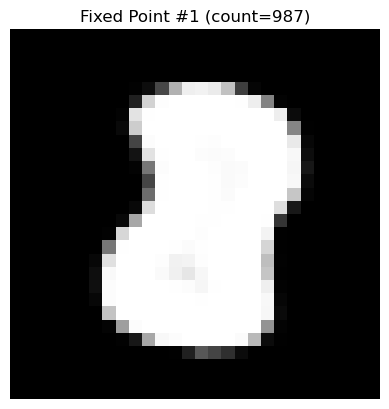

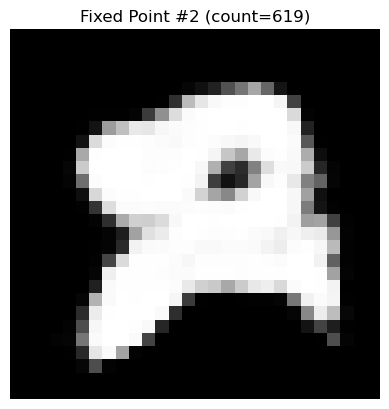

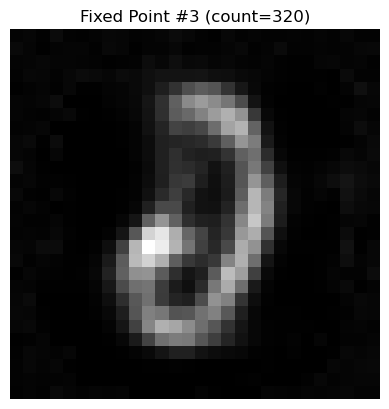


===== VISUALIZING TOP CYCLE ATTRACTORS =====


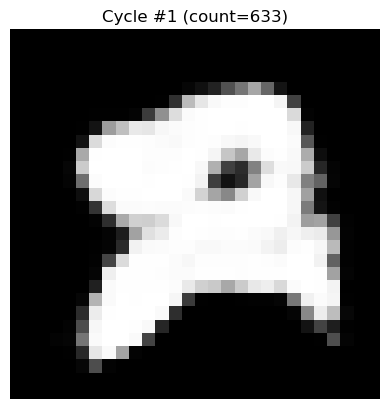

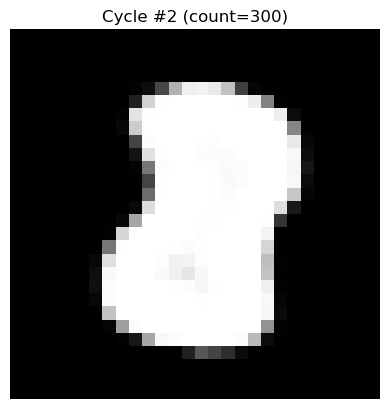

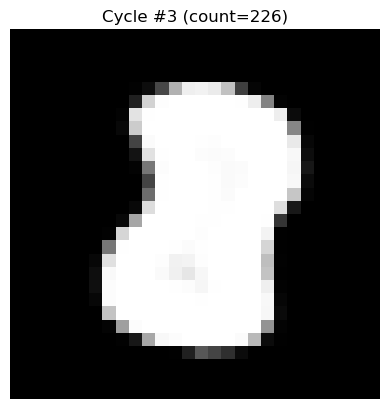

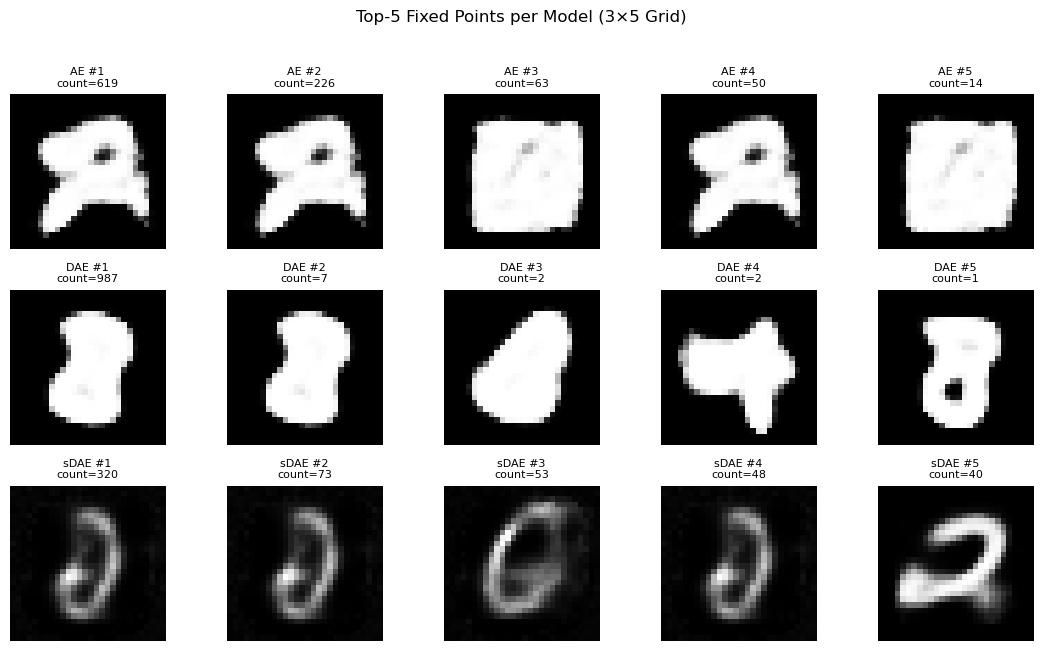


===== AVERAGE MSE COMPARISON ACROSS MODELS =====
AE: mean MSE = 0.307693
DAE: mean MSE = 0.321480
sDAE: mean MSE = 0.280738


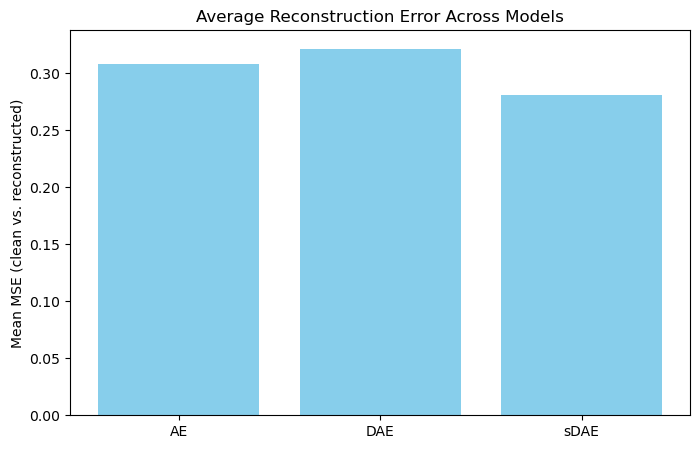

In [11]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)
        x = add_noise(x_clean, noise_factor=0.81)

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)

        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1
            

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

    mean_mse = total_mse / trials
    return fixed_point_count, cycles_detected, mean_mse


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse = test_random_points(model, model_name=name, trials=1000, iters=10000)
    trials = 1000

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),
        "mean_mse": mean_mse
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    print(f"{name}: fixed={fp_values} cycles={cy_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()




===== RANDOM DYNAMICAL TEST RESULTS =====

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in tri

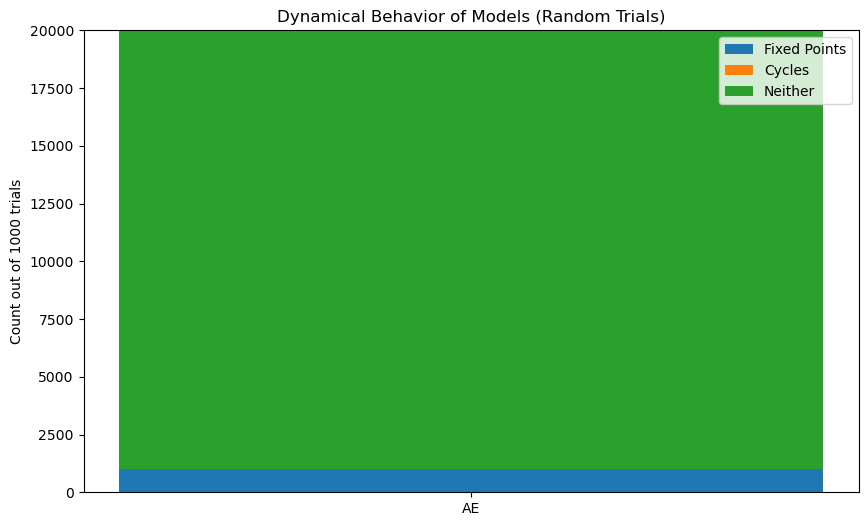

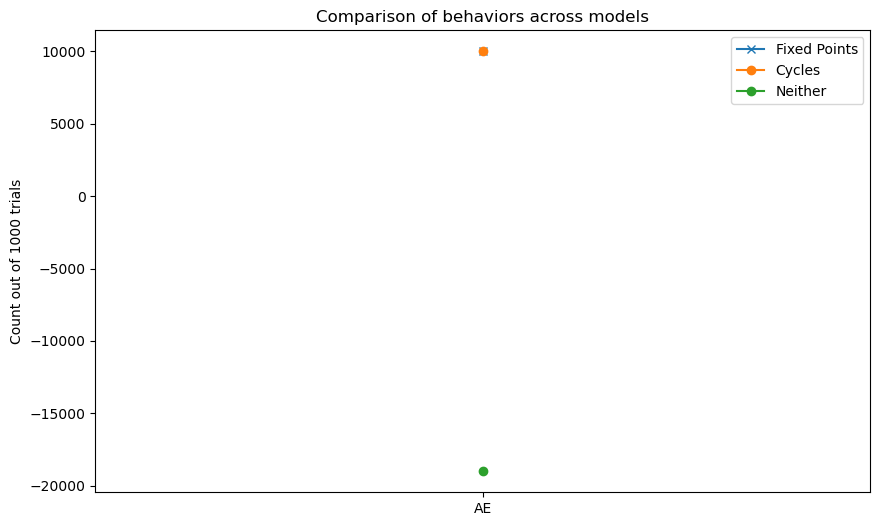


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=6273
2. count=2237
3. count=610
4. count=433
5. count=128

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=6190
2. count=1071
3. count=803
4. count=556
5. count=218

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


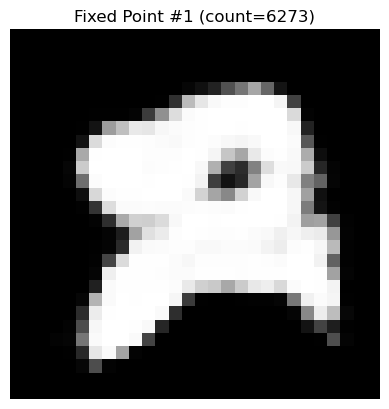

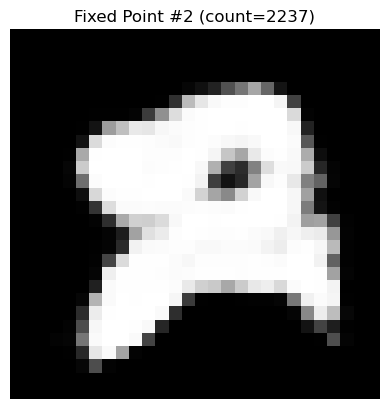

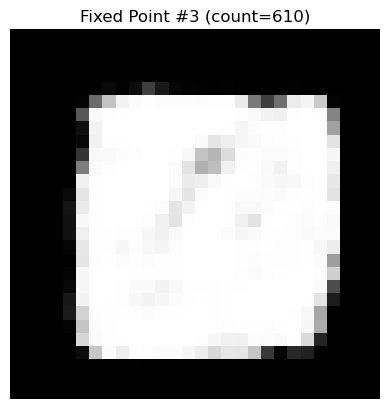


===== VISUALIZING TOP CYCLE ATTRACTORS =====


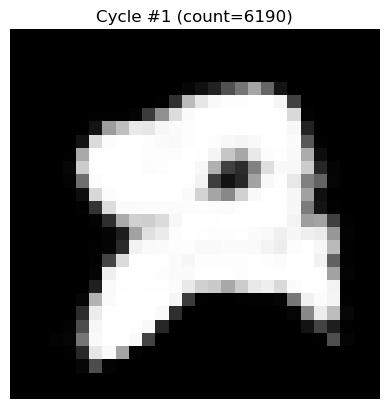

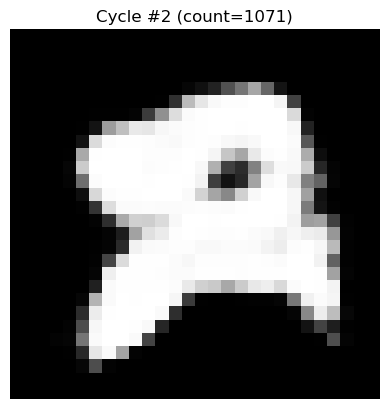

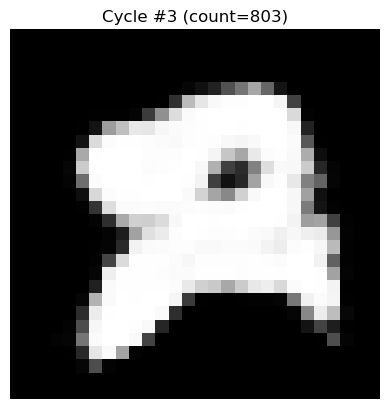

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in trial: 17
Cycle found in trial: 17
Fixed point 

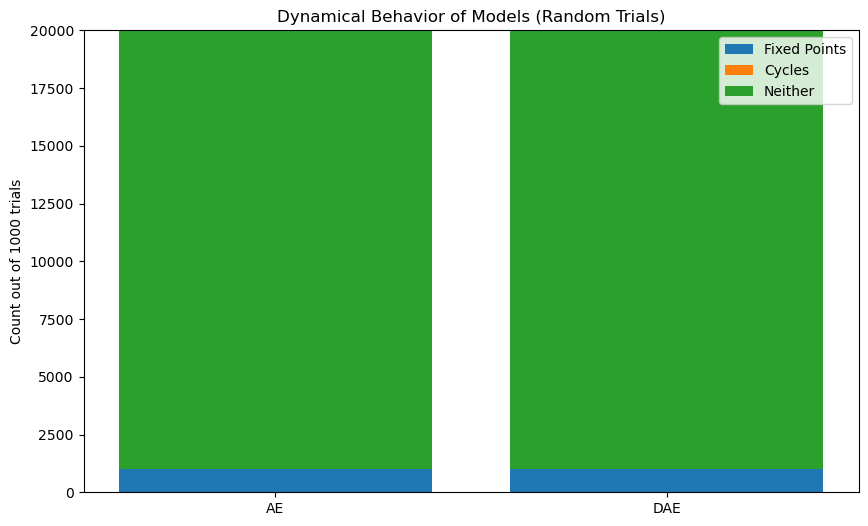

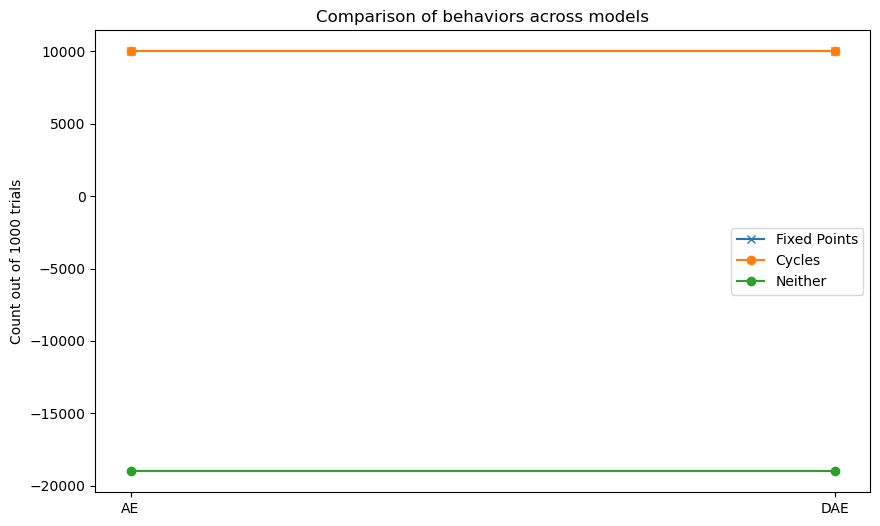


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=9890
2. count=6273
3. count=2237
4. count=610
5. count=433

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=6190
2. count=2790
3. count=2348
4. count=1535
5. count=1131

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


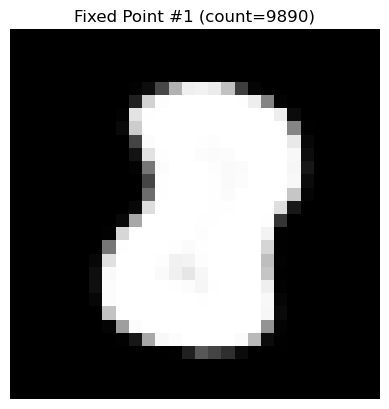

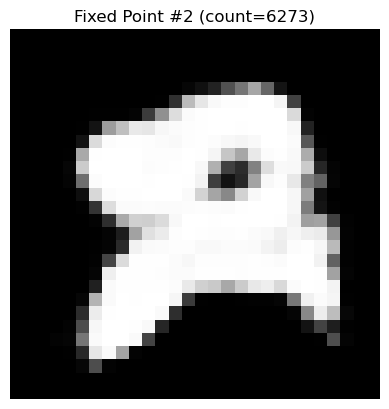

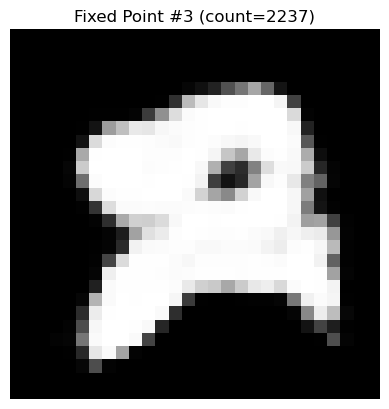


===== VISUALIZING TOP CYCLE ATTRACTORS =====


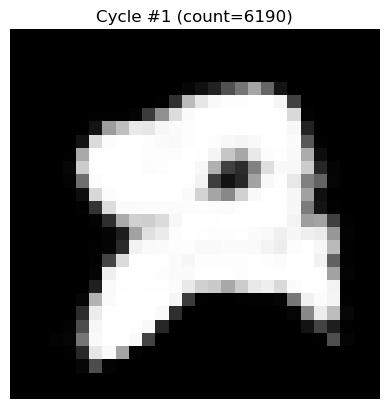

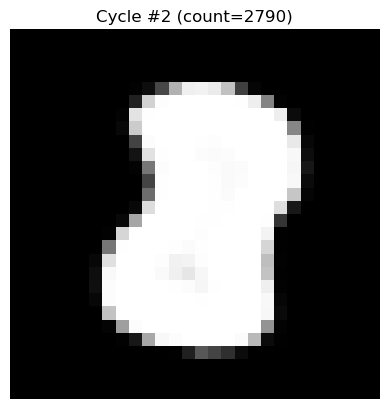

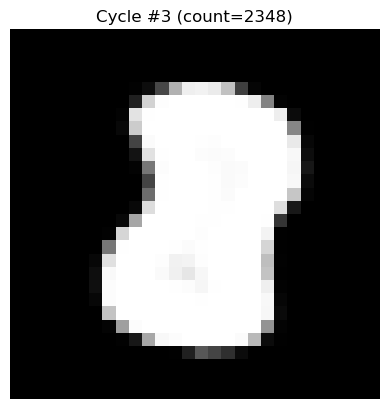

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in trial: 17
Cycle found in trial: 17
Fixed point found in trial: 18
Cycle found in trial: 18
Fixed poin

In [ ]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)
        x = add_noise(x_clean, noise_factor=0.81)

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)

        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1
            

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

    mean_mse = total_mse / trials
    return fixed_point_count, cycles_detected, mean_mse


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse = test_random_points(model, model_name=name, trials=10000, iters=10000)
    trials = 1000

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),
        "mean_mse": mean_mse
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    print(f"{name}: fixed={fp_values} cycles={cy_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()



===== RANDOM DYNAMICAL TEST RESULTS =====

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in tri

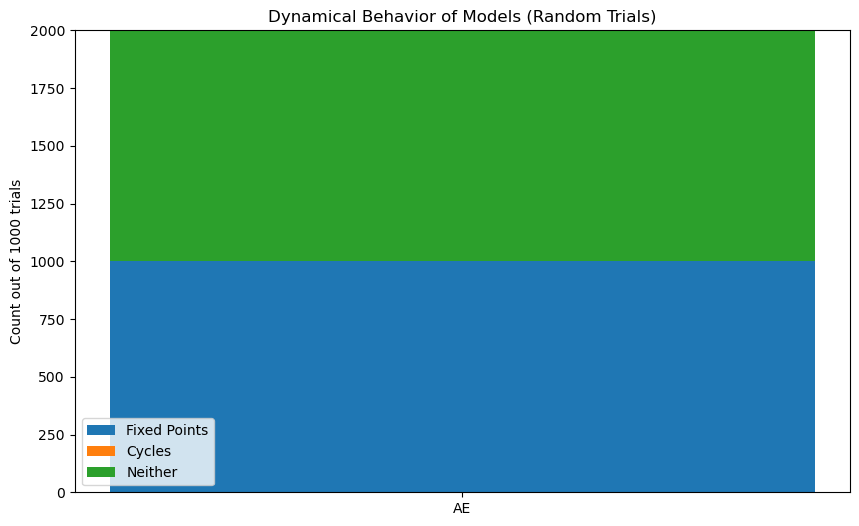

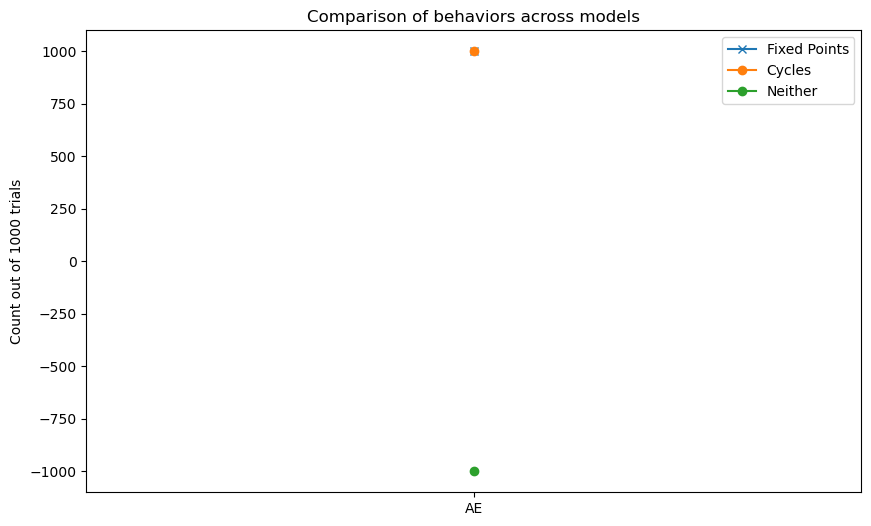


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=637
2. count=214
3. count=65
4. count=43
5. count=18

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=614
2. count=119
3. count=71
4. count=68
5. count=25

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


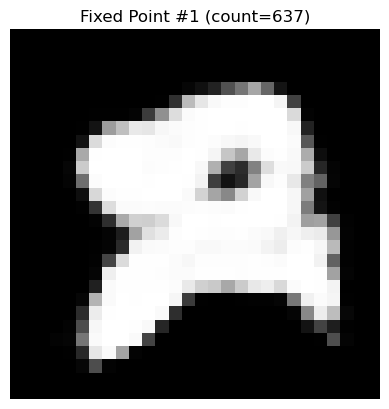

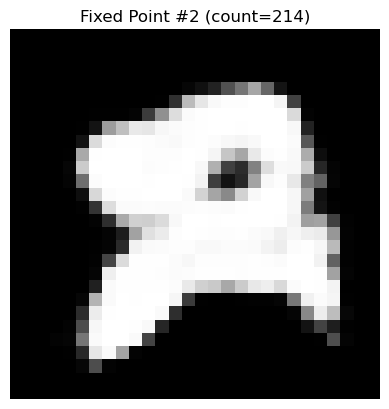

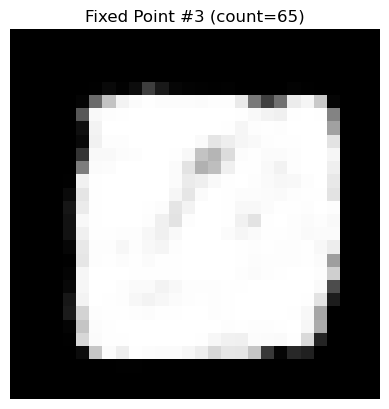


===== VISUALIZING TOP CYCLE ATTRACTORS =====


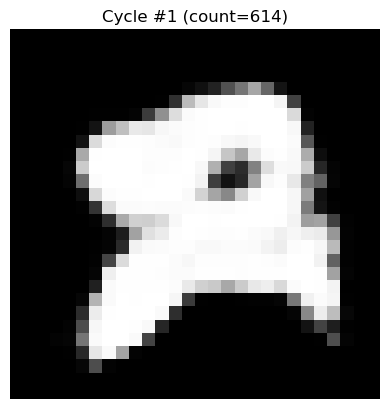

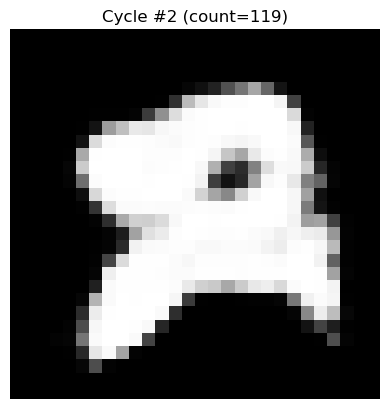

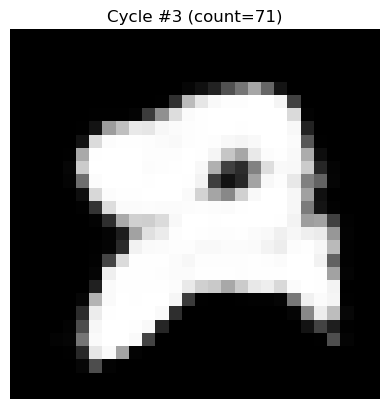

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in trial: 17
Cycle found in trial: 17
Fixed point 

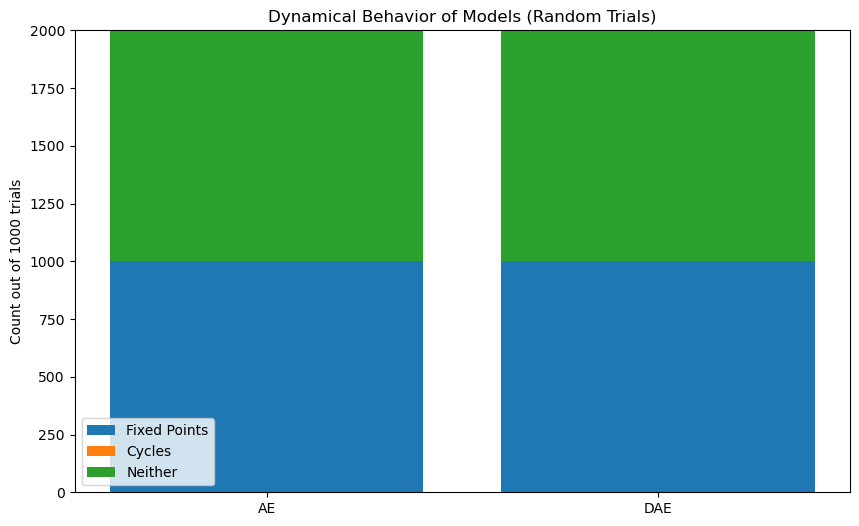

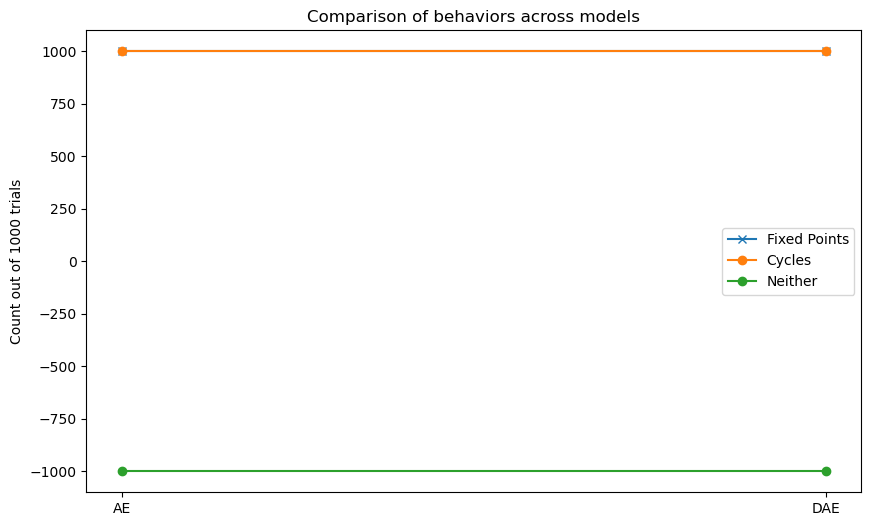


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=988
2. count=637
3. count=214
4. count=65
5. count=43

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=614
2. count=299
3. count=233
4. count=157
5. count=119

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


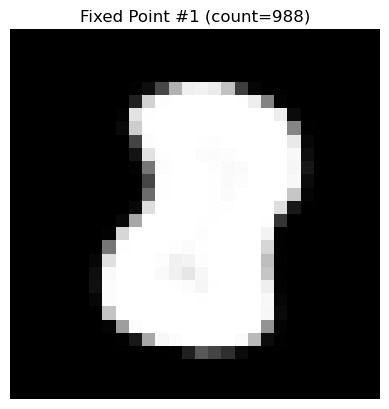

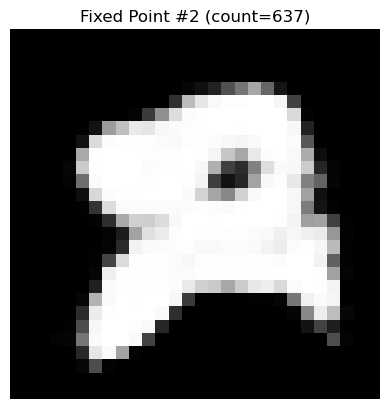

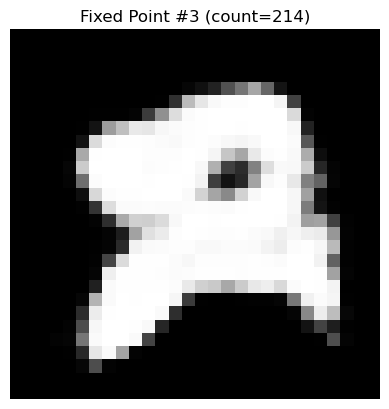


===== VISUALIZING TOP CYCLE ATTRACTORS =====


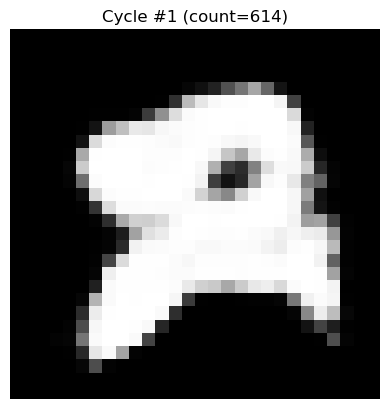

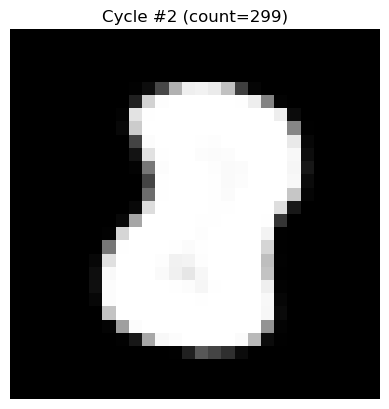

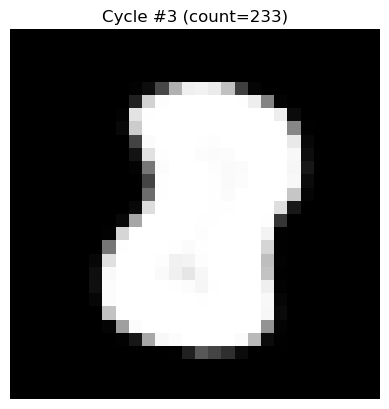

Fixed point found in trial: 0
Cycle found in trial: 0
Fixed point found in trial: 1
Cycle found in trial: 1
Fixed point found in trial: 2
Cycle found in trial: 2
Fixed point found in trial: 3
Cycle found in trial: 3
Fixed point found in trial: 4
Cycle found in trial: 4
Fixed point found in trial: 5
Cycle found in trial: 5
Fixed point found in trial: 6
Cycle found in trial: 6
Fixed point found in trial: 7
Cycle found in trial: 7
Fixed point found in trial: 8
Cycle found in trial: 8
Fixed point found in trial: 9
Cycle found in trial: 9
Fixed point found in trial: 10
Cycle found in trial: 10
Fixed point found in trial: 11
Cycle found in trial: 11
Fixed point found in trial: 12
Cycle found in trial: 12
Fixed point found in trial: 13
Cycle found in trial: 13
Fixed point found in trial: 14
Cycle found in trial: 14
Fixed point found in trial: 15
Cycle found in trial: 15
Fixed point found in trial: 16
Cycle found in trial: 16
Fixed point found in trial: 17
Cycle found in trial: 17
Fixed point 

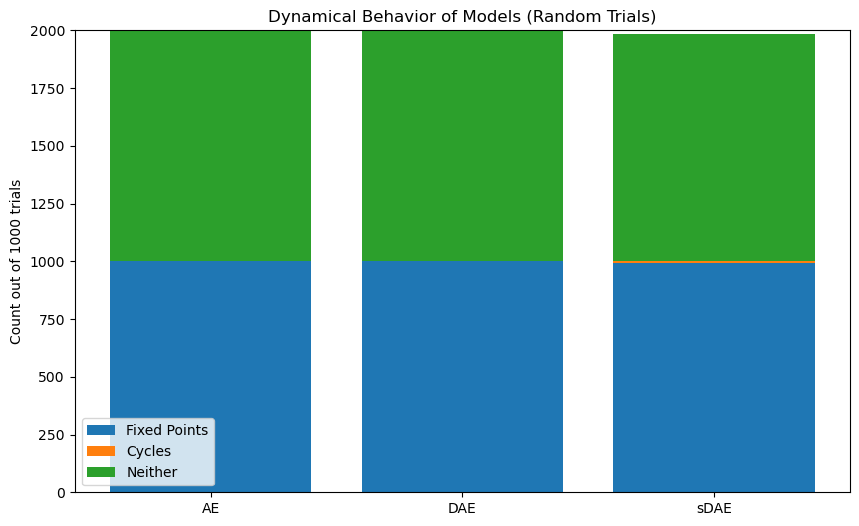

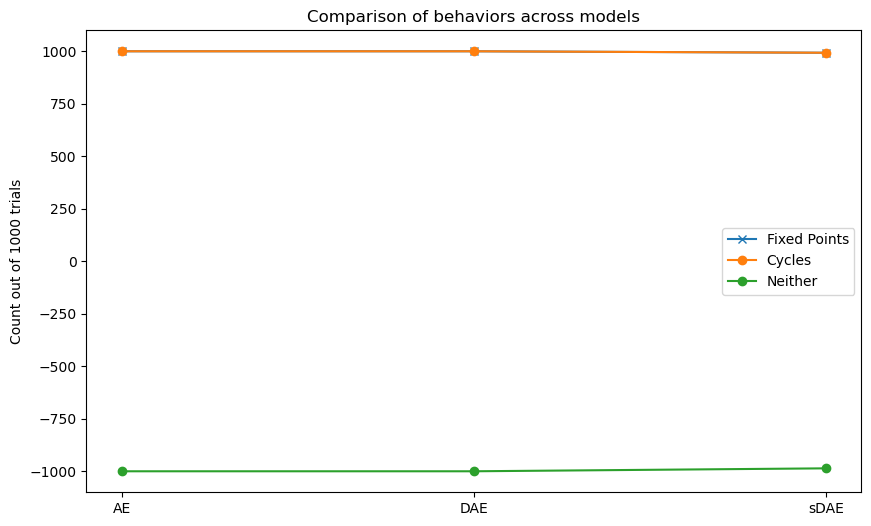


===== MOST FREQUENT FIXED-POINT ATTRACTORS =====
1. count=988
2. count=637
3. count=310
4. count=214
5. count=65

===== MOST FREQUENT CYCLE ATTRACTORS =====
1. count=614
2. count=299
3. count=233
4. count=157
5. count=119

===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====


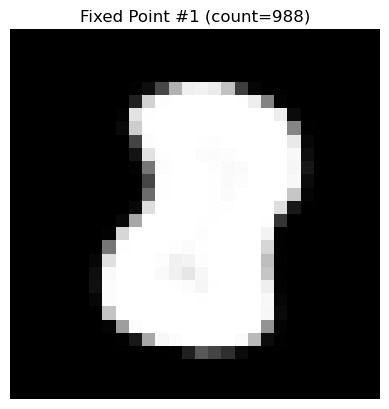

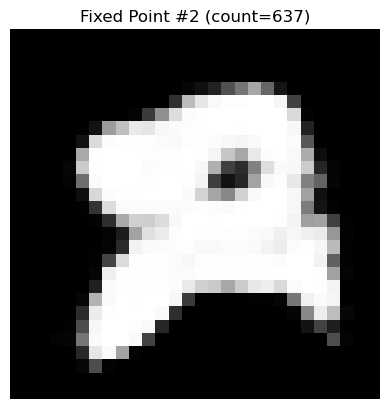

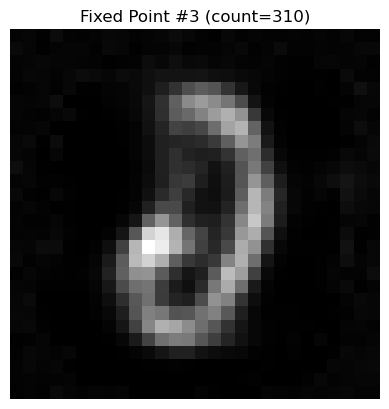


===== VISUALIZING TOP CYCLE ATTRACTORS =====


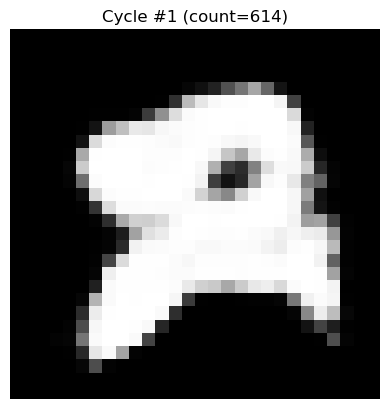

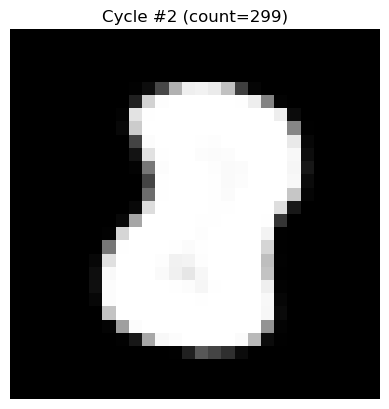

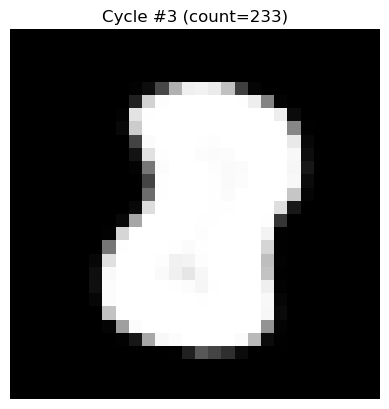

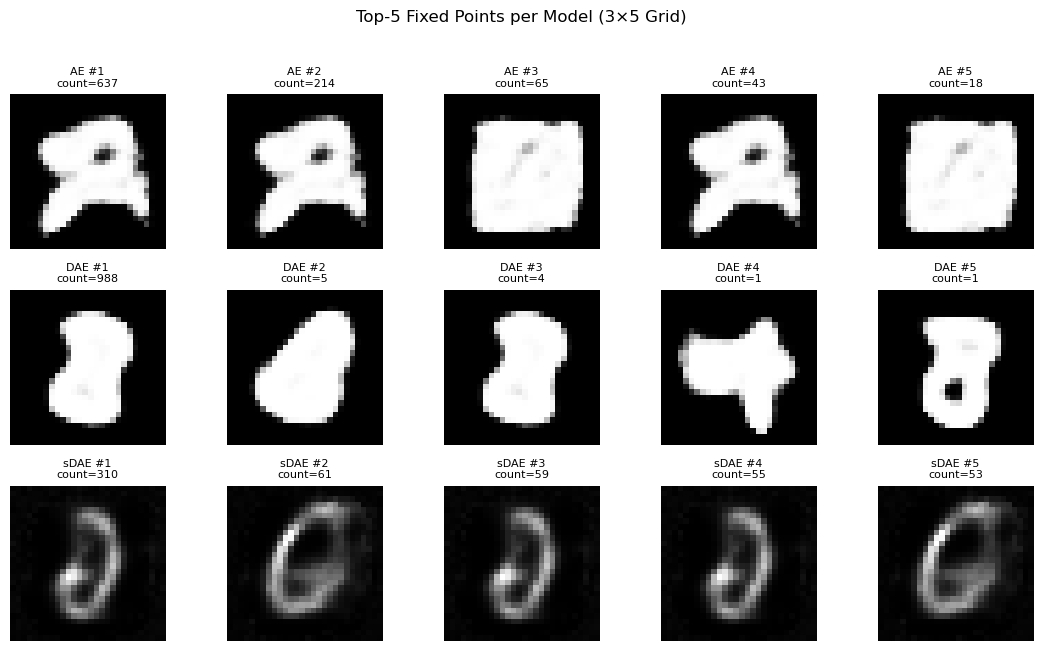


===== AVERAGE MSE COMPARISON ACROSS MODELS =====
AE: mean MSE = 0.307267
DAE: mean MSE = 0.321657
sDAE: mean MSE = 0.280937


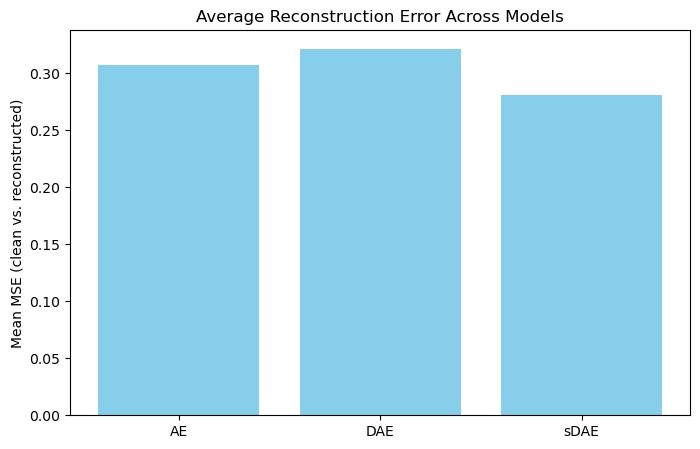

In [17]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)
        x = add_noise(x_clean, noise_factor=0.81)

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)

        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1
            

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

    mean_mse = total_mse / trials
    return fixed_point_count, cycles_detected, mean_mse


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse = test_random_points(model, model_name=name, trials=1000, iters=100000)
    trials = 1000

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),
        "mean_mse": mean_mse
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    print(f"{name}: fixed={fp_values} cycles={cy_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()


In [ ]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)
        x = add_noise(x_clean, noise_factor=0.81)

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)

        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1
            

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

    mean_mse = total_mse / trials
    return fixed_point_count, cycles_detected, mean_mse


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse = test_random_points(model, model_name=name, trials=100000, iters=10000)
    trials = 1000

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),
        "mean_mse": mean_mse
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    print(f"{name}: fixed={fp_values} cycles={cy_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()


In [ ]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)
        x = add_noise(x_clean, noise_factor=0.81)

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)

        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1
            

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

    mean_mse = total_mse / trials
    return fixed_point_count, cycles_detected, mean_mse


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse = test_random_points(model, model_name=name, trials=1000000, iters=10000)
    trials = 1000

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),
        "mean_mse": mean_mse
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    print(f"{name}: fixed={fp_values} cycles={cy_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()


In [ ]:
from collections import Counter  # <-- NEW: to count most frequent attractors

overall_results = {}   # <-- add this BEFORE the for-loop
fp_values = []
cy_values = []

# NEW: counters for most frequent attractors
fp_counter = Counter()      # counts distinct fixed-point representatives
cycle_counter = Counter()   # counts distinct cycle representatives
# Track top fixed points per model (AE, DAE, SDAE, etc.)
model_fp_counters = {name: Counter() for name in models.keys()}

loss_fn = torch.nn.MSELoss(reduction='mean')   # <-- NEW: loss function

# Random trials
@torch.no_grad()
def test_random_points(model, model_name, trials=2000, iters=2000):
    """
    Randomly initializes x in [0,1], repeatedly applies model(x),
    and checks if the model converges to a fixed point.
    Also computes mean MSE between the clean (pre-noise) image and final output.
    """
    fixed_point_count = 0
    cycles_detected = 0
    total_mse = 0.0           # <-- accumulate MSE across trials

    for _ in range(trials):
        # start at a random point in the MNIST input space
        x_clean = torch.rand((1, 1, 28, 28)).to(device)
        x = add_noise(x_clean, noise_factor=0.81)

        # Maps trajectories of given trial
        trajectory = []

        for i in range(iters):
            trajectory.append(x.detach().clone())
            x_next = model(x)
            x = x_next.detach()
            
        # Compute MSE between clean image and model output
        mse = loss_fn(x, x_clean).item()
        total_mse += mse

        trajectory_tensor = torch.stack([t.flatten() for t in trajectory])

        # If it detects a fixed point, increment the fixed point count
        fp_idx = detect_fixed_point(trajectory_tensor)
        cyc_start, cyc_period = detect_cycle(trajectory_tensor)

        if fp_idx is not None:
            fixed_point_count += 1
            print('Fixed point found in trial:', _)
            fp_values.append(fp_idx)
            rep_fp = trajectory_tensor[fp_idx]
            key_fp = tuple((rep_fp.cpu().numpy().round(3)).tolist())
            fp_counter[key_fp] += 1
            model_fp_counters[model_name][key_fp] += 1
            

        if cyc_start is not None:
            cycles_detected += 1
            print('Cycle found in trial:', _)
            cy_values.append(cyc_period)
            rep_cy = trajectory_tensor[cyc_start]
            key_cy = tuple((rep_cy.cpu().numpy().round(3)).tolist())
            cycle_counter[key_cy] += 1

    mean_mse = total_mse / trials
    return fixed_point_count, cycles_detected, mean_mse


print("\n===== RANDOM DYNAMICAL TEST RESULTS =====\n")

for name, model in models.items():
    model.eval()
    fp_hits, cycle_hits, mean_mse = test_random_points(model, model_name=name, trials=1000, iters=100000)
    trials = 1000

    overall_results[name] = {
        "fixed": fp_hits,
        "cycles": cycle_hits,
        "neither": trials - (fp_hits + cycle_hits),
        "mean_mse": mean_mse
    }

    print(f"{name}: fixed={fp_hits}/1000, cycles={cycle_hits}/1000")
    print(f"{name}: fixed={fp_values} cycles={cy_values}")
    print(f"{name}: mean MSE vs clean image = {mean_mse:.6f}")

    # ----- BAR CHART (fixed vs cycles vs neither) -----
    labels = list(overall_results.keys())
    fixed_vals  = [overall_results[m]["fixed"] for m in labels]
    cycle_vals  = [overall_results[m]["cycles"] for m in labels]
    neither_vals = [overall_results[m]["neither"] for m in labels]
    
    plt.figure(figsize=(10,6))
    plt.bar(labels, fixed_vals, label="Fixed Points")
    plt.bar(labels, cycle_vals, bottom=fixed_vals, label="Cycles")
    plt.bar(labels, neither_vals, bottom=[fixed_vals[i] + cycle_vals[i] for i in range(len(labels))], label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Dynamical Behavior of Models (Random Trials)")
    plt.legend()
    plt.show()
    
    # ----- LINE GRAPH (comparison of each behavior type) -----
    plt.figure(figsize=(10,6))
    plt.plot(labels, fixed_vals, marker='x', label="Fixed Points")
    plt.plot(labels, cycle_vals, marker='o', label="Cycles")
    plt.plot(labels, neither_vals, marker='o', label="Neither")
    plt.ylabel("Count out of 1000 trials")
    plt.title("Comparison of behaviors across models")
    plt.legend()
    plt.show()

    # ----- NEW: print most frequent attractors (top-5 each) -----
    print("\n===== MOST FREQUENT FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(5), 1):
        print(f"{i}. count={count}")
    
    print("\n===== MOST FREQUENT CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(5), 1):
        print(f"{i}. count={count}")

    
    print("\n===== VISUALIZING TOP FIXED-POINT ATTRACTORS =====")
    for i, (k, count) in enumerate(fp_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Fixed Point #{i} (count={count})")
        plt.axis("off")
        plt.show()
    
    print("\n===== VISUALIZING TOP CYCLE ATTRACTORS =====")
    for i, (k, count) in enumerate(cycle_counter.most_common(3), 1):
        arr = np.array(k).reshape(28, 28)
        plt.imshow(arr, cmap="gray")
        plt.title(f"Cycle #{i} (count={count})")
        plt.axis("off")
        plt.show()

# ===== 3×5 DISPLAY OF TOP FIXED POINTS PER MODEL =====
rows = len(model_fp_counters)   # expect 3 (AE, DAE, SDAE)
cols = 5                        # top-5 per model
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))

# Ensure axes is 2D even if rows==1
if rows == 1:
    axes = np.array([axes])

for r, (mname, counter) in enumerate(model_fp_counters.items()):
    top5 = counter.most_common(cols)
    for c in range(cols):
        ax = axes[r, c]
        if c < len(top5):
            k, count = top5[c]
            arr = np.array(k).reshape(28, 28)
            ax.imshow(arr, cmap="gray")
            ax.set_title(f"{mname} #{c+1}\ncount={count}", fontsize=8)
            ax.axis("off")
        else:
            ax.axis("off")

plt.suptitle("Top-5 Fixed Points per Model (3×5 Grid)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ===== FINAL: COMPARE AVERAGE MSE ACROSS MODELS =====
print("\n===== AVERAGE MSE COMPARISON ACROSS MODELS =====")
for mname, res in overall_results.items():
    print(f"{mname}: mean MSE = {res['mean_mse']:.6f}")

plt.figure(figsize=(8,5))
plt.bar(list(overall_results.keys()), [res["mean_mse"] for res in overall_results.values()],
        color='skyblue')
plt.ylabel("Mean MSE (clean vs. reconstructed)")
plt.title("Average Reconstruction Error Across Models")
plt.show()
